# Example Mini-project: Detecting the anomalous activity of a ship’s engine

**Welcome to mini-project: Detecting the anomalous activity of a ship’s engine! This is an example of a mini project starter notebook and is not for formal submission. Instructions have been provided to support familiarity with the mini-project framework and guidance format ahead of your first assessed Mini-project.**

This mini-project allows you to dive deep into a real-world challenge, applying and honing the data science skills you've been cultivating so far. In this immersive exploration into detecting the anomalous activity of a ship’s engine, you can practically apply the concepts you've learned over the past few weeks.

A poorly maintained ship engine in the supply chain industry can lead to inefficiencies, increased fuel consumption, higher risks of malfunctions, and potential safety hazards. Your challenge in this project is to apply critical thinking and ML concepts to design and implement a robust anomaly detection model.

Please set aside approximately **12 hours** to complete the mini-project.

<br></br>

## **Example Business context**
You are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). As you work through this project, keep in mind that, typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

Your task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Therefore, you’ll explore the data and:
- employ preprocessing and feature engineering
- perform anomaly detection.

You must prepare a report illustrating your insights to the prospective stakeholders, explaining your approach in identifying anomalies, presenting your findings and including recommendations.

<br></br>

> **Disclaimer**
>
> Please note that although a real-life data set was provided, the business context in this project is fictitious. Any resemblance to companies and persons (living or dead) is coincidental. The course designers and hosts assume no responsibility or liability for any errors or omissions in the content of the business context and data sets. The information in the data sets is provided on an 'as is' basis with no guarantees of completeness, accuracy, usefulness, or timeliness.

<br></br>

## **Example Objective**
By the end of this mini-project, you will be able to understand and apply statistical and ML methods for detecting anomalies.

In the Notebook, you will:
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.

You will also write a report summarising the results of your findings and recommendations.

<br></br>

## **Example Assessment criteria**
By completing this project, you will be able to provide evidence that you can:
- demonstrate enhanced problem-solving skills and proposed strategic solutions by systematically analysing complex organisational challenges
- identify meaningful patterns in complex data to evidence advanced critical and statistical thinking skills
- select statistical techniques appropriate to a solutions design approach and evidence the ability to evaluate their effectiveness
- demonstrate enhanced data representation and improved model performance by systematically implementing relevant techniques
- design innovative solutions through critically selecting, evaluating and implementing effective unsupervised learning techniques.

<br></br>




## **Example Project guidance**
1. Import the required libraries and data set with the provided URL.
2. View the DataFrame and perform EDA, including identifying missing or duplicate values.
3. Generate the descriptive statistics of the data, including:
 - observing the mean for each feature
 - identifying the median
4. Visualise the data to determine the distribution and extreme values.
5. Perform anomaly detection with a statistical method and identify possible anomalies. Specifically:
  - Use the interquartile range (IQR) method to identify outliers for each feature.
  - Create a new column (corresponding to each feature) that will indicate (in binary – 0,1) if the value of that feature is an outlier as per IQR calculations.
  - Use IQR to identify the number of features that must simultaneously be in outlier condition, in order for a sample to be classified as an outlier, such that the total percentage of samples identified as outliers falls within the 1-5% range.
  - Record your thoughts and observations.
6. Perform anomaly detection with ML models:
  - Using one-class SVM,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
  - Using Isolation Forest,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
7. Document your approach and major inferences from the data analysis and describe which method (and parameters) provided the best results and why.
8. When you’ve completed the activity:
  - Download your completed Notebook as an IPYNB (Jupyter Notebook). Save the file as follows: LastName_FirstName_CAM_C101_Wx_Mini-project.ipynb
  - Prepare a detailed report (between 800-1000 words) that includes:
    - an overview of the problem that is being addressed in this project
    - an overview of your approach, with a clear visualisation of your anomaly detection approach
    - key figures and tables of the main results
    - interpretation of the anomaly detection results
    - an evaluation of the effectiveness of 2D PCA plots in highlighting outliers
    - recommendations based on gathered evidence.
  - Save the document as a PDF named according to the following convention: LastName_FirstName_CAM_C101_Wx_Mini-project.pdf.



# Solution proposed

# 1. Import the required libraries and data set with the provided URL.

In [2]:
# Import the necessary libraries.
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# URL to import data set from GitHub.
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'

# Read the CSV file into a new DataFrame.
df = pd.read_csv(url)

# Display the first few rows of the DataFrame.
df.head()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220


# 2. View the DataFrame and perform EDA, including identifying missing or duplicate values.

In [4]:
# Display basic information about the dataset to understand its structure, data types, and non-null values.

# Check the data types in the data.
df.info()
print("\nInsight: The dataset contains 19535 entries and 6 columns: 'Engine rpm' (int64/numerical), 'Lub oil pressure' (float64/numerical), 'Fuel pressure' (float64/numerical), 'Coolant pressure' (float64/numerical), 'lub oul temp' (float64/numerical) and 'coolant temp' (float64/numerical). There are no missing values based on the non-null count matching the total entries.")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19535 entries, 0 to 19534
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Engine rpm        19535 non-null  int64  
 1   Lub oil pressure  19535 non-null  float64
 2   Fuel pressure     19535 non-null  float64
 3   Coolant pressure  19535 non-null  float64
 4   lub oil temp      19535 non-null  float64
 5   Coolant temp      19535 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 915.8 KB

Insight: The dataset contains 19535 entries and 6 columns: 'Engine rpm' (int64/numerical), 'Lub oil pressure' (float64/numerical), 'Fuel pressure' (float64/numerical), 'Coolant pressure' (float64/numerical), 'lub oul temp' (float64/numerical) and 'coolant temp' (float64/numerical). There are no missing values based on the non-null count matching the total entries.


In [5]:
# Display the first few rows of the dataset to get a quick overview of the data format.
print("\n### First 5 rows of the dataset ###")
print(df.head())
print("\nInsight: We can see the 'Engine rpm' column contains integer values around 600-700, 'Lub oil pressure' + 'Fuel pressure' + 'Coolant pressure' contains decimal numbers in 1-8 and 'lub oil temp' + 'Coolant temp' contains decimal numbers in 60-90. *In the first 5 rows only.")


### First 5 rows of the dataset ###
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         682          2.391656       4.617196          2.848982   
1         605          5.466877       6.424361          5.727520   
2         658          3.434232       3.680896          1.678708   
3         749          2.094656       7.120927          1.639670   
4         676          3.538228       5.956472          3.225336   

   lub oil temp  Coolant temp  
0     76.272417     69.884609  
1     73.222679     74.907314  
2     88.089916     78.704806  
3     77.661625     82.386700  
4     75.226352     67.153220  

Insight: We can see the 'Engine rpm' column contains integer values around 600-700, 'Lub oil pressure' + 'Fuel pressure' + 'Coolant pressure' contains decimal numbers in 1-8 and 'lub oil temp' + 'Coolant temp' contains decimal numbers in 60-90. *In the first 5 rows only.


In [6]:
# Check for missing values in each column.
# This is crucial for data cleaning and understanding data completeness.
print("\n### Missing Values Check ###")
print(df.isnull().sum())
print("\nInsight: As observed from `df.info()`, there are no missing values in any column, which simplifies our analysis.")



### Missing Values Check ###
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64

Insight: As observed from `df.info()`, there are no missing values in any column, which simplifies our analysis.


# 3. Generate the descriptive statistics of the data, including:
 - observing the mean for each feature
 - identifying the median

In [7]:
# Display descriptive statistics for numerical columns.
# This provides a summary of the central tendency, dispersion, and shape of the distribution.
print("\n### Descriptive Statistics ###")
print(df.describe())


### Descriptive Statistics ###
         Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
count  19535.000000      19535.000000   19535.000000      19535.000000   
mean     791.239263          3.303775       6.655615          2.335369   
std      267.611193          1.021643       2.761021          1.036382   
min       61.000000          0.003384       0.003187          0.002483   
25%      593.000000          2.518815       4.916886          1.600466   
50%      746.000000          3.162035       6.201720          2.166883   
75%      934.000000          4.055272       7.744973          2.848840   
max     2239.000000          7.265566      21.138326          7.478505   

       lub oil temp  Coolant temp  
count  19535.000000  19535.000000  
mean      77.643420     78.427433  
std        3.110984      6.206749  
min       71.321974     61.673325  
25%       75.725990     73.895421  
50%       76.817350     78.346662  
75%       78.071691     82.915411  
max       89.

# 4. Visualise the data to determine the distribution and extreme values.

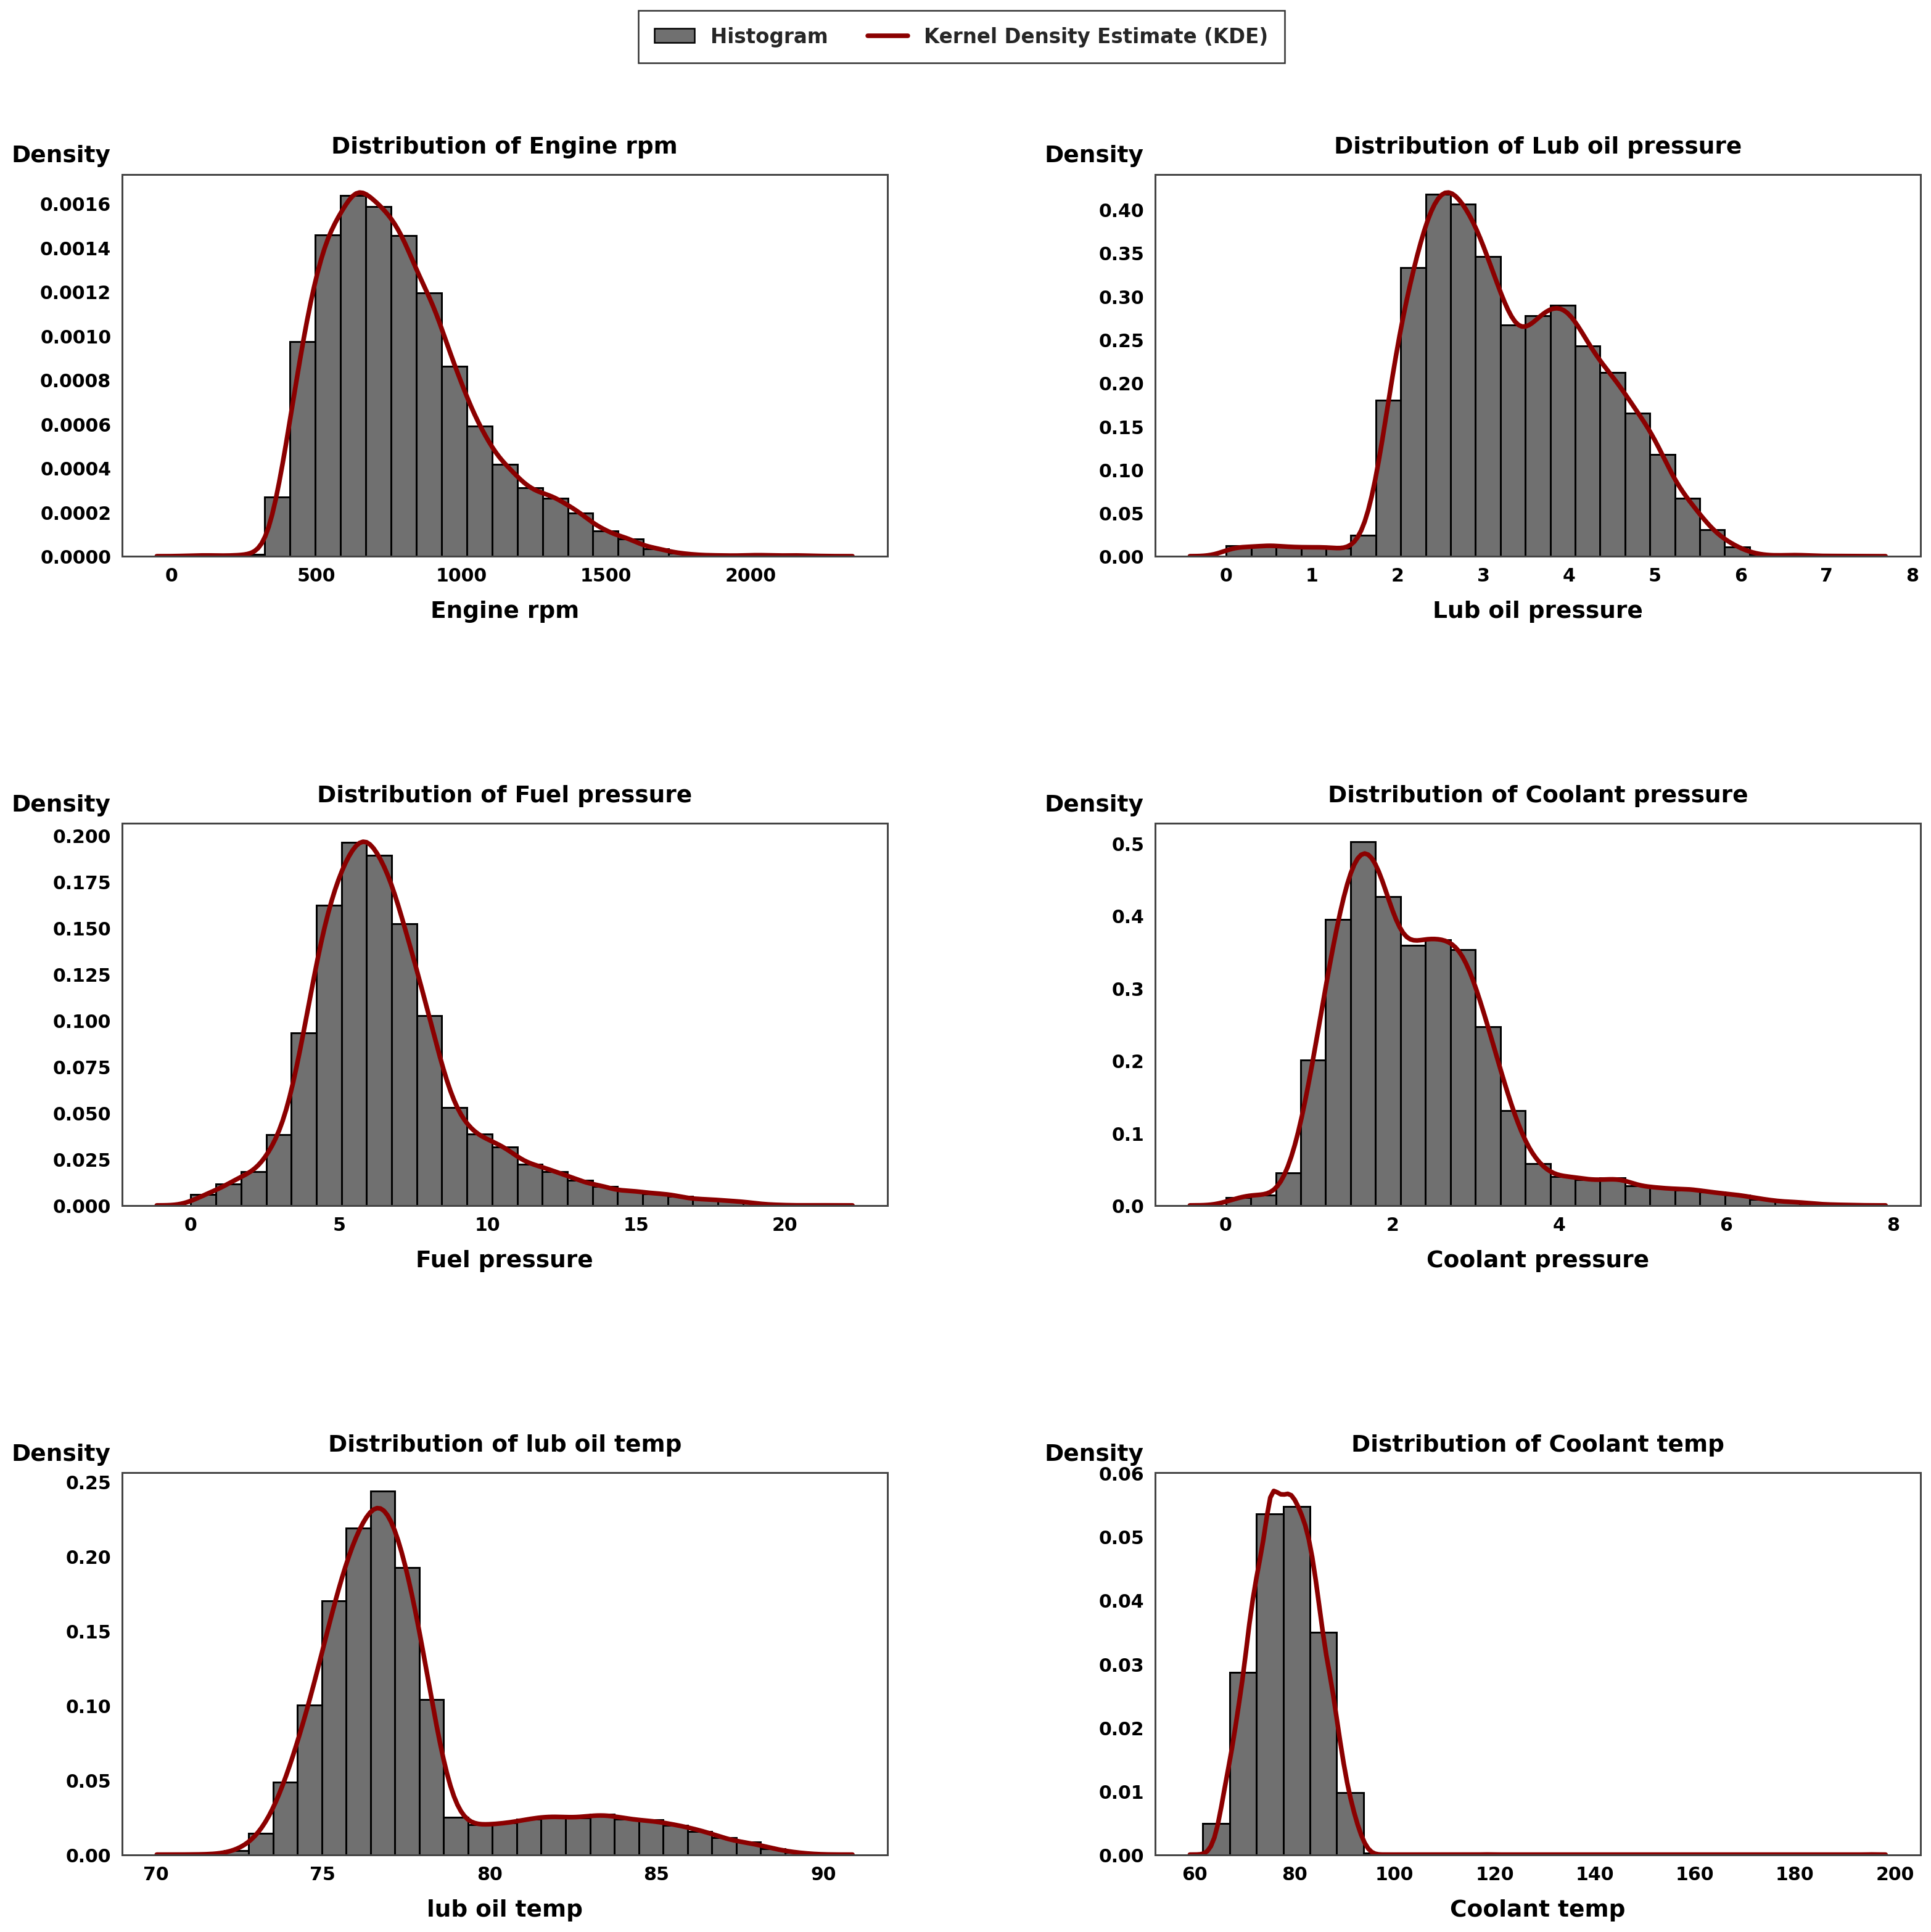


Insight: The histograms provide a visual representation of the distribution of each feature. The grey bars show the empirical density of the observations, while the dark red Kernel Density Estimate (KDE) curve provides a smoothed approximation of the underlying distribution. These plots facilitate the identification of skewness, multimodal patterns, and potential abnormal behaviour prior to applying anomaly detection algorithms.


In [8]:

import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# High-quality display for Google Colab
plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Scientific style
sns.set_style("white")

# Layout
n_cols = 2
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5.8 * n_rows)
)

axes = axes.flatten()

# Style colours
BAR_COLOR = "#707070"
EDGE_COLOR = "#000000"
KDE_COLOR = "#8B0000"
TEXT_COLOR = "#000000"
SPINE_COLOR = "#444444"

for i, column in enumerate(df.columns):

    data = df[column].dropna()

    # Histogram
    sns.histplot(
        data,
        bins=25,
        stat="density",
        color=BAR_COLOR,
        edgecolor=EDGE_COLOR,
        linewidth=1.2,
        alpha=1,
        ax=axes[i]
    )

    # KDE
    sns.kdeplot(
        data,
        color=KDE_COLOR,
        linewidth=3,
        ax=axes[i]
    )

    # Title
    axes[i].set_title(
        f"Distribution of {column}",
        fontsize=15,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=14
    )

    # X label
    axes[i].set_xlabel(
        column,
        fontsize=15,
        fontweight="bold",
        color=TEXT_COLOR,
        labelpad=10
    )

    # Horizontal Y label (same style as boxplots)
    axes[i].set_ylabel(
        "Density",
        fontsize=15,
        fontweight="bold",
        rotation=0,
        color=TEXT_COLOR
    )

    # Move the label outside the axis
    axes[i].yaxis.set_label_coords(-0.08, 1.02)

    # Remove grid
    axes[i].grid(False)

    # Axis styling
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(1.2)

    # Tick styling
    axes[i].tick_params(
        axis="both",
        labelsize=12,
        colors=TEXT_COLOR,
        width=1.2
    )

    for tick in axes[i].get_xticklabels() + axes[i].get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(TEXT_COLOR)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_elements = [
    Patch(
        facecolor=BAR_COLOR,
        edgecolor=EDGE_COLOR,
        label="Histogram"
    ),
    Line2D(
        [0], [0],
        color=KDE_COLOR,
        lw=3,
        label="Kernel Density Estimate (KDE)"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor="#333333",
    facecolor="white",
    framealpha=1,
    borderpad=0.8,
    bbox_to_anchor=(0.5, 1.01),
    prop={"weight": "bold", "size": 13}
)

# Spacing between plots
plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.92,
    bottom=0.05,
    hspace=0.70,
    wspace=0.35
)

plt.show()

print(
    "\nInsight: The histograms provide a visual representation of the distribution of each "
    "feature. The grey bars show the empirical density of the observations, while the dark "
    "red Kernel Density Estimate (KDE) curve provides a smoothed approximation of the "
    "underlying distribution. These plots facilitate the identification of skewness, "
    "multimodal patterns, and potential abnormal behaviour prior to applying anomaly "
    "detection algorithms."
)

At first sight, no variable seem to follow a perfect normal distribution.

The **histograms** and **KDE curves** indicate that the features exhibit different distribution patterns, with several variables showing **positive skewness**, **heavy tails**, or **multimodal behaviour**. These characteristics suggest the presence of extreme observations and multiple operating regimes, ***supporting the use of robust anomaly detection methods that do not assume normally distributed data***.

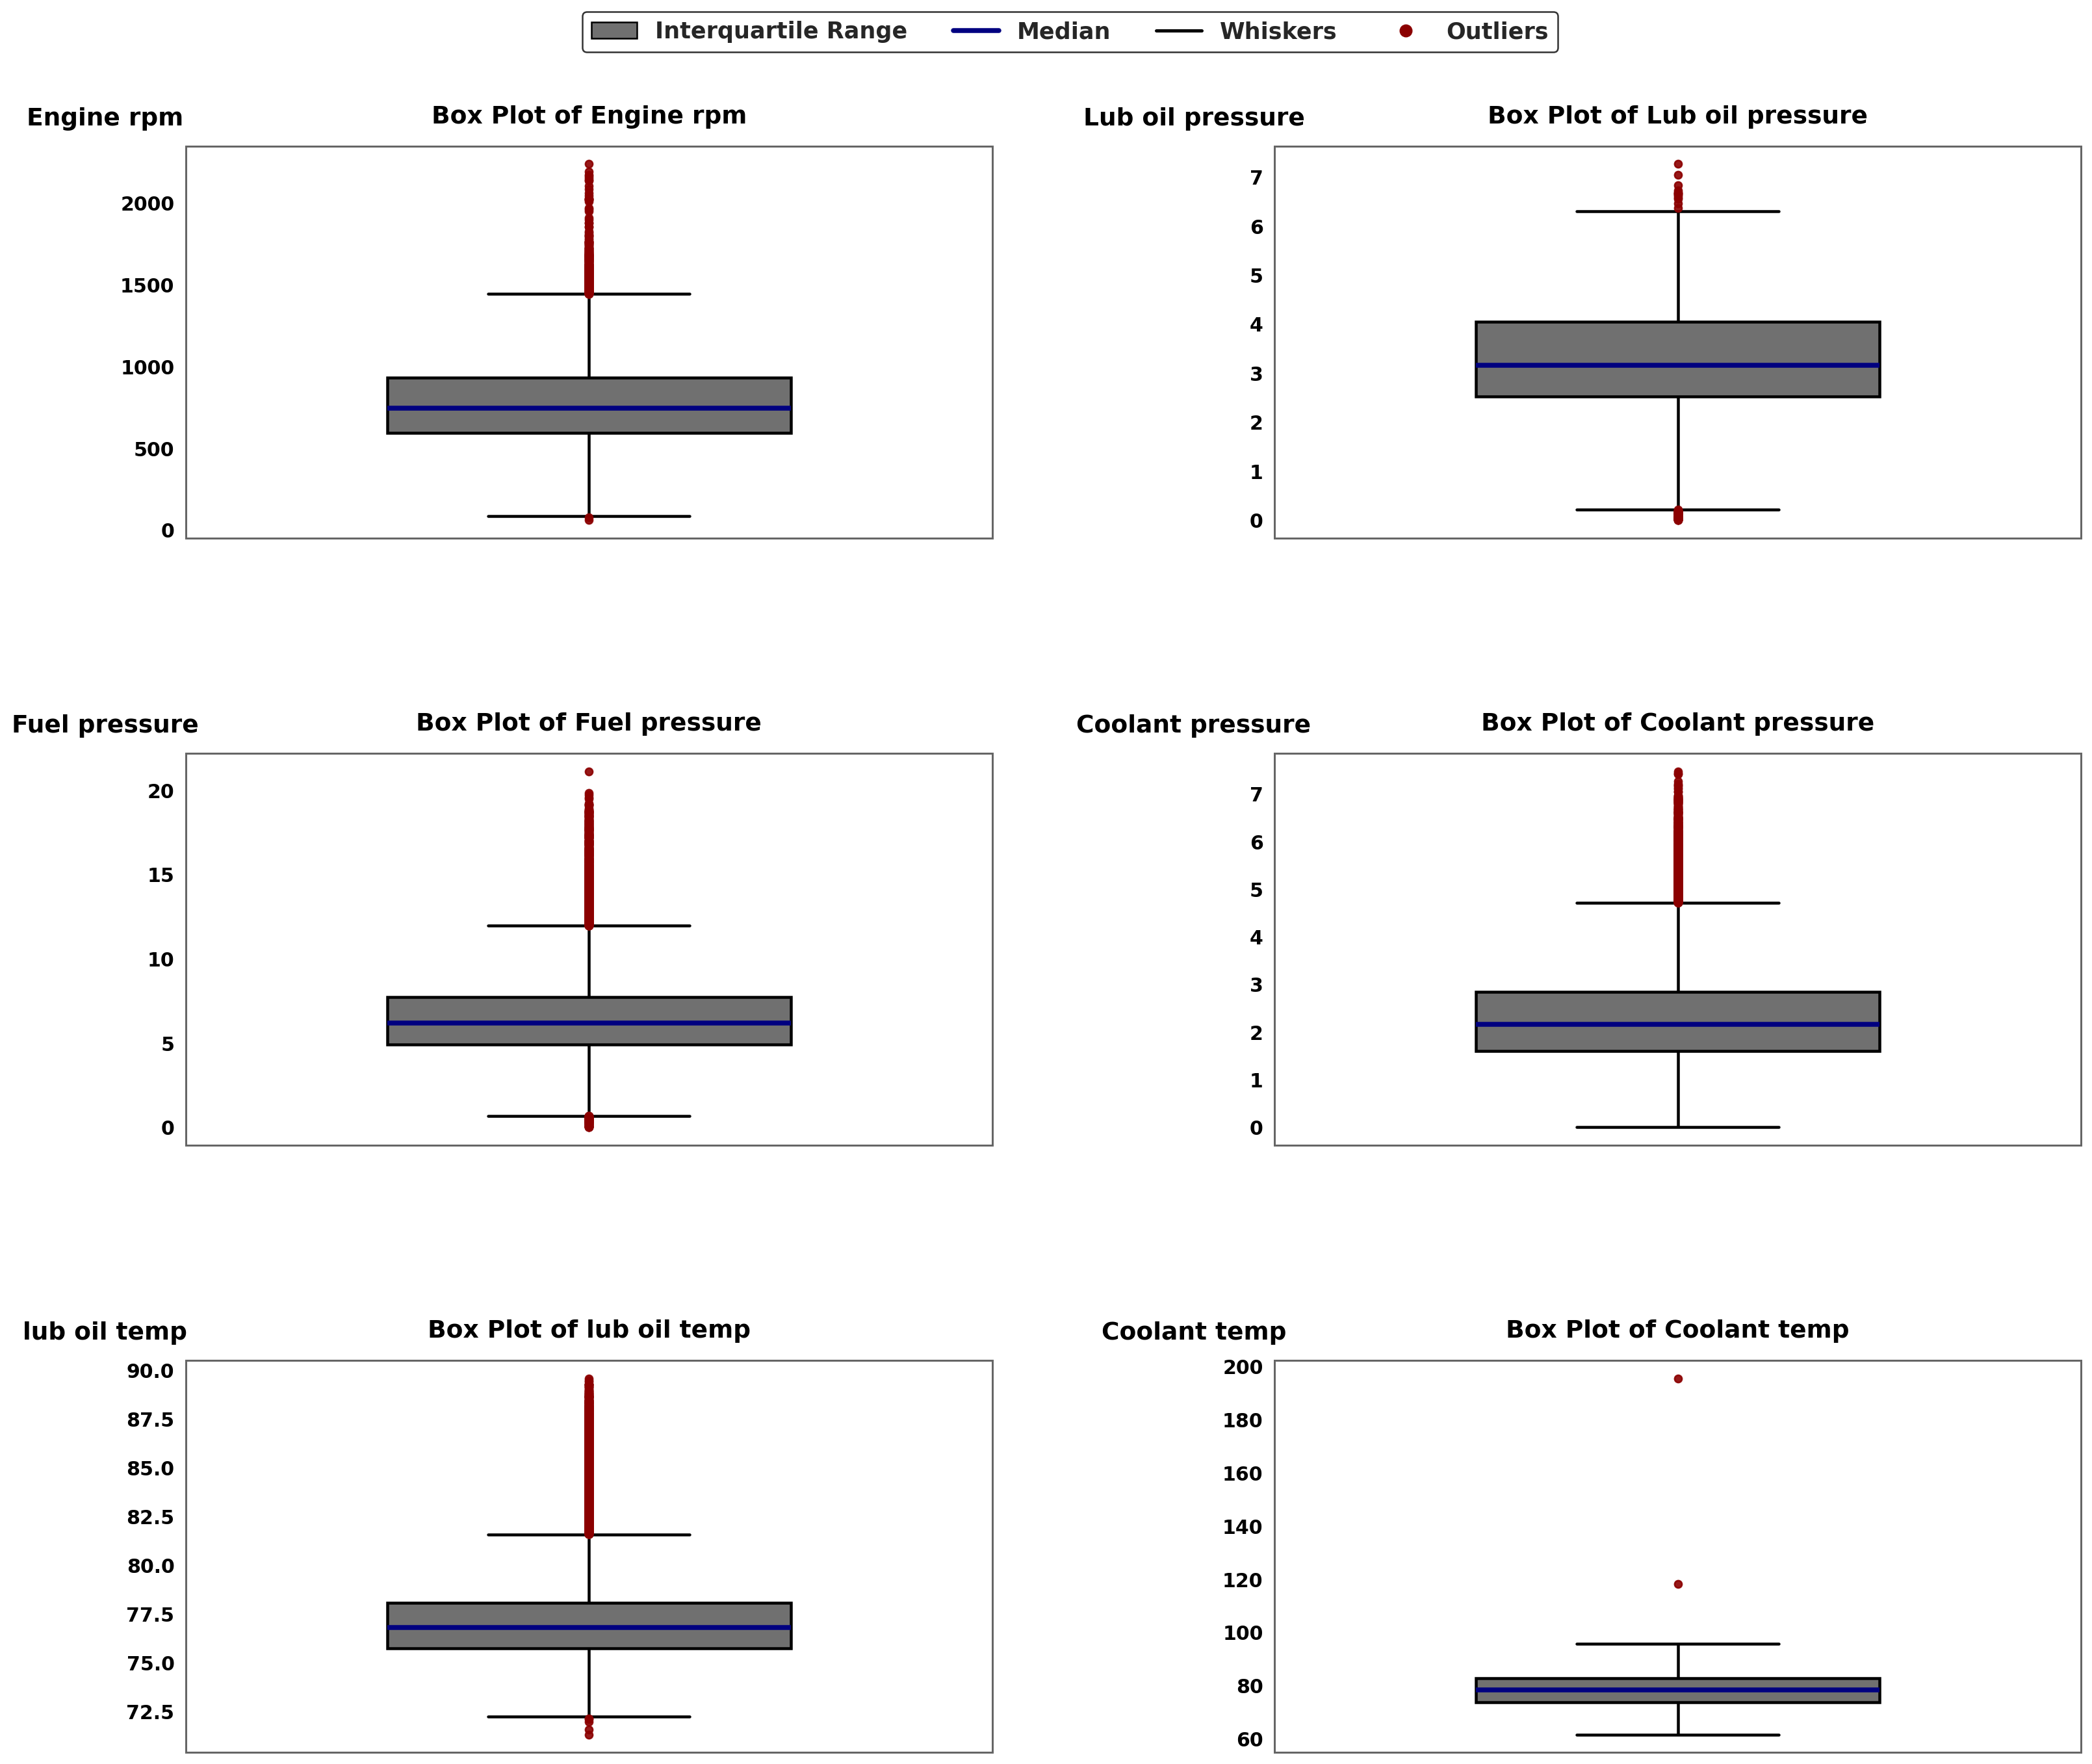


Insight: The box plots summarise each feature using the interquartile range, median, whiskers, and potential outliers. The grey box represents the central 50% of the data, the navy blue line indicates the median, the black whiskers show the non-outlying range, and the dark red points mark potential outliers.


In [9]:
import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# High-quality display for Google Colab
plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

sns.set_style("white")

n_cols = 2
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5.2 * n_rows)
)

axes = axes.flatten()

BOX_COLOR = "#707070"
EDGE_COLOR = "#000000"
MEDIAN_COLOR = "#000080"
OUTLIER_COLOR = "#8B0000"
TEXT_COLOR = "#000000"
SPINE_COLOR = "#666666"

for i, column in enumerate(df.columns):

    data = df[column].dropna()

    sns.boxplot(
        y=data,
        ax=axes[i],
        width=0.5,
        color=BOX_COLOR,
        boxprops=dict(edgecolor=EDGE_COLOR, linewidth=1.8),
        whiskerprops=dict(color=EDGE_COLOR, linewidth=1.8),
        capprops=dict(color=EDGE_COLOR, linewidth=1.8),
        medianprops=dict(color=MEDIAN_COLOR, linewidth=3),
        flierprops=dict(
            marker="o",
            markerfacecolor=OUTLIER_COLOR,
            markeredgecolor=OUTLIER_COLOR,
            markersize=4.5,
            alpha=0.9
        )
    )

    axes[i].set_title(
        f"Box Plot of {column}",
        fontsize=15,
        fontweight="bold",
        color=TEXT_COLOR,
        pad=14
    )

    axes[i].set_xlabel("")

    axes[i].set_ylabel(
        column,
        fontsize=15,
        fontweight="bold",
        rotation=0,
        color=TEXT_COLOR
    )

    axes[i].yaxis.set_label_coords(-0.10, 1.04)

    axes[i].grid(False)

    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(1.2)

    axes[i].tick_params(
        axis="both",
        labelsize=12,
        colors=TEXT_COLOR,
        width=1
    )

    for tick in axes[i].get_xticklabels() + axes[i].get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(TEXT_COLOR)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

legend_elements = [
    Patch(
        facecolor=BOX_COLOR,
        edgecolor=EDGE_COLOR,
        label="Interquartile Range"
    ),
    Line2D(
        [0], [0],
        color=MEDIAN_COLOR,
        lw=3,
        label="Median"
    ),
    Line2D(
        [0], [0],
        color=EDGE_COLOR,
        lw=2,
        label="Whiskers"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="white",
        markerfacecolor=OUTLIER_COLOR,
        markeredgecolor=OUTLIER_COLOR,
        markersize=7,
        label="Outliers"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=True,
    edgecolor="#333333",
    facecolor="white",
    framealpha=1,
    bbox_to_anchor=(0.5, 1.01),
    prop={"weight": "bold", "size": 14}
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.93,
    bottom=0.05,
    hspace=0.55,
    wspace=0.35
)

plt.show()

print(
    "\nInsight: The box plots summarise each feature using the interquartile range, median, "
    "whiskers, and potential outliers. The grey box represents the central 50% of the data, "
    "the navy blue line indicates the median, the black whiskers show the non-outlying range, "
    "and the dark red points mark potential outliers."
)

IndexError: index 6 is out of bounds for axis 0 with size 6

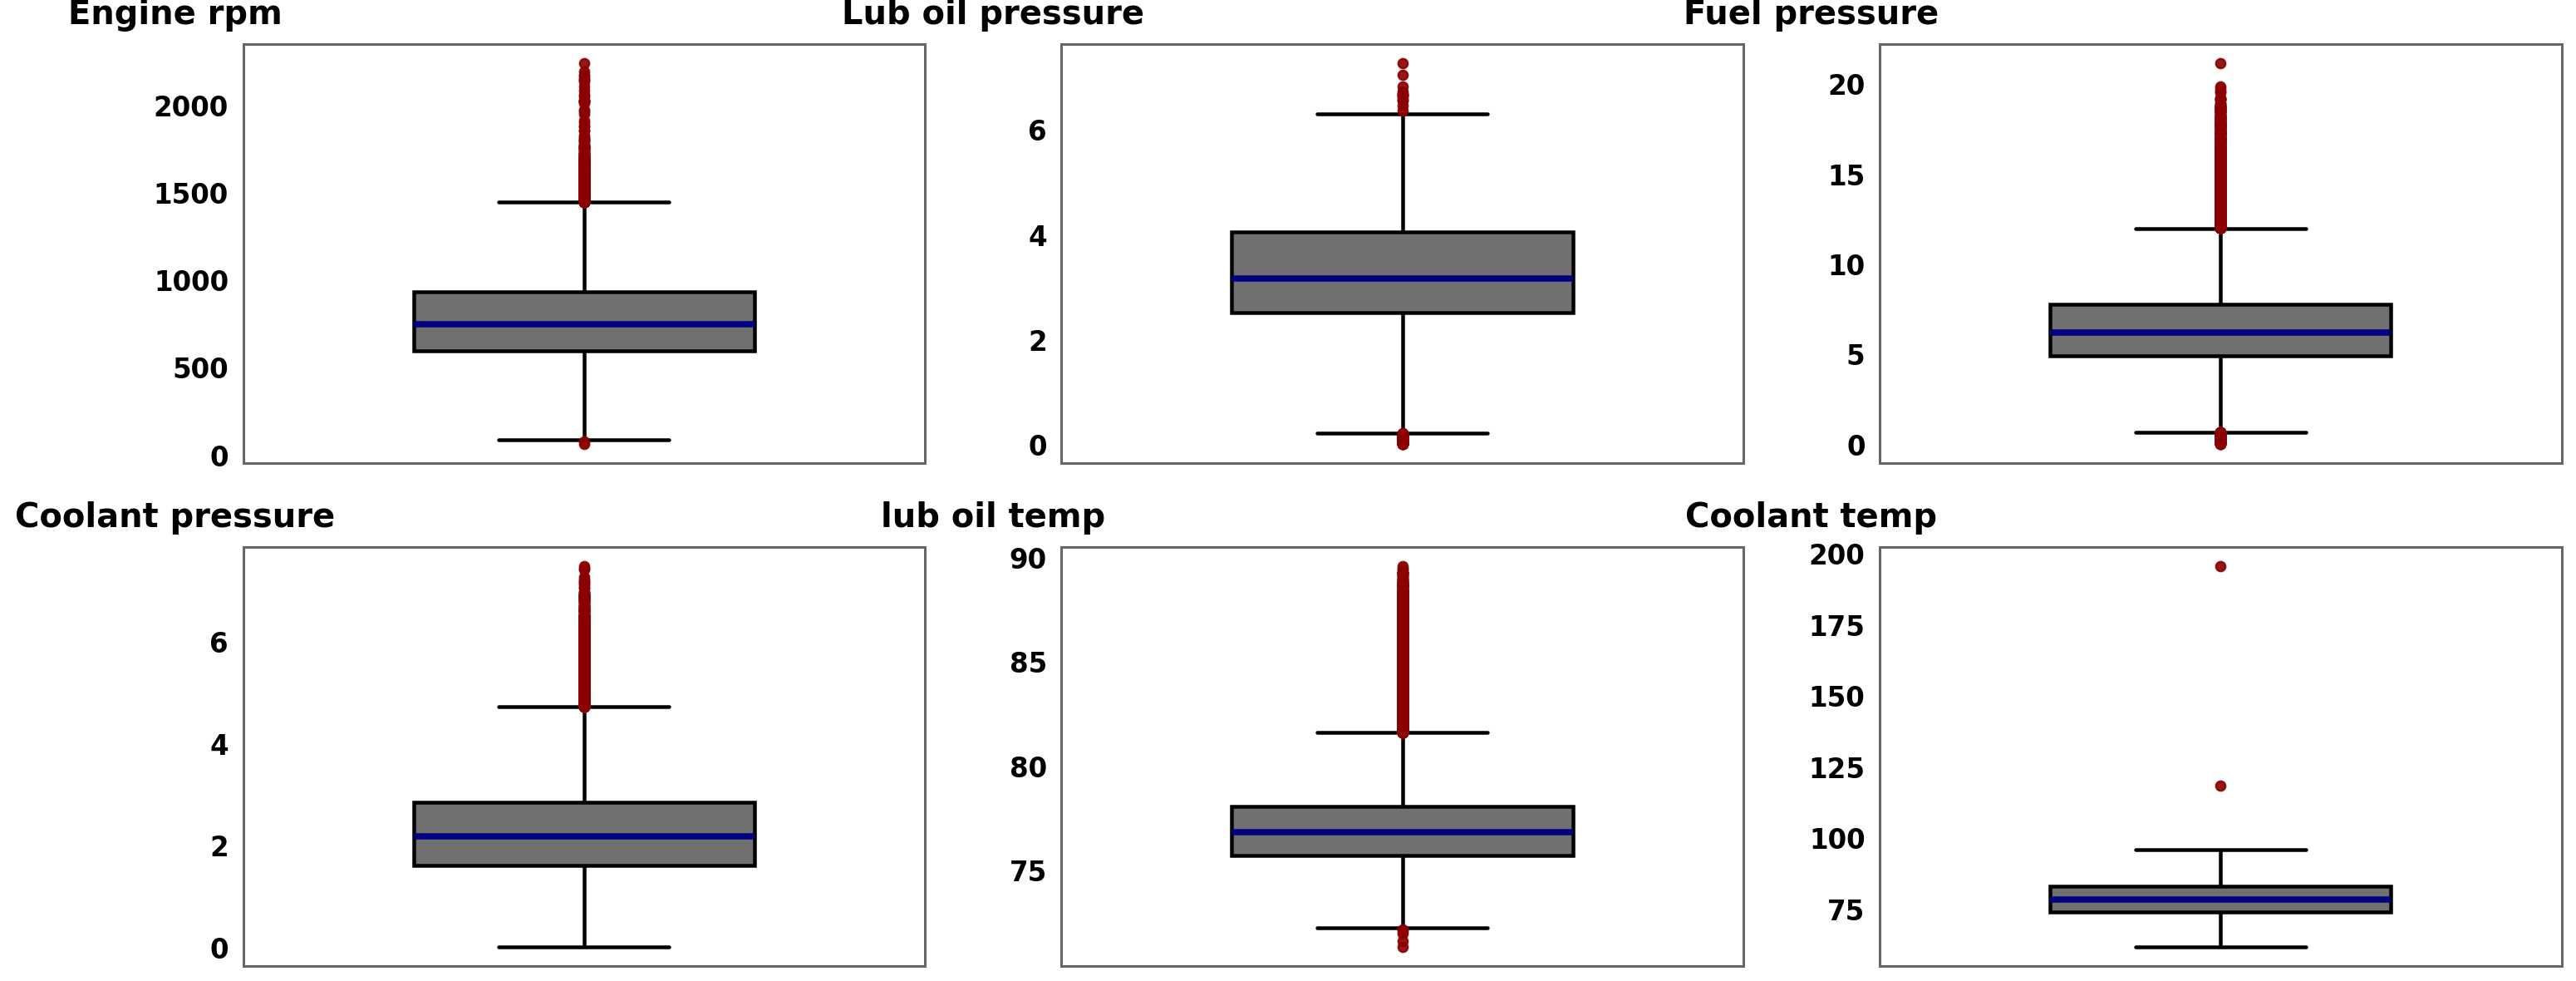

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ==========================================================
# High-quality display settings
# ==========================================================

plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

sns.set_style("white")

# ==========================================================
# Layout (3 columns × 2 rows)
# ==========================================================

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 8)
)

axes = axes.flatten()

# ==========================================================
# Style
# ==========================================================

BOX_COLOR = "#707070"
EDGE_COLOR = "#000000"
MEDIAN_COLOR = "#000080"
OUTLIER_COLOR = "#8B0000"
TEXT_COLOR = "#000000"
SPINE_COLOR = "#666666"

# ==========================================================
# Draw boxplots
# ==========================================================

for i, column in enumerate(df.columns):

    data = df[column].dropna()

    sns.boxplot(
        y=data,
        ax=axes[i],
        width=0.5,
        color=BOX_COLOR,
        boxprops=dict(
            edgecolor=EDGE_COLOR,
            linewidth=1.8
        ),
        whiskerprops=dict(
            color=EDGE_COLOR,
            linewidth=1.8
        ),
        capprops=dict(
            color=EDGE_COLOR,
            linewidth=1.8
        ),
        medianprops=dict(
            color=MEDIAN_COLOR,
            linewidth=3
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor=OUTLIER_COLOR,
            markeredgecolor=OUTLIER_COLOR,
            markersize=4.5,
            alpha=0.9
        )
    )

    # # Title
    # axes[i].set_title(
    #     f"Box Plot of {column}",
    #     fontsize=17,
    #     fontweight="bold",
    #     color=TEXT_COLOR,
    #     pad=14
    # )

    # Remove x label
    axes[i].set_xlabel("")

    # Horizontal y label
    axes[i].set_ylabel(
        column,
        fontsize=16,
        fontweight="bold",
        rotation=0,
        color=TEXT_COLOR
    )

    axes[i].yaxis.set_label_coords(-0.10, 1.03)

    # Remove grid
    axes[i].grid(False)

    # Spine style
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(1.2)

    # Tick style
    axes[i].tick_params(
        axis="both",
        labelsize=13,
        colors=TEXT_COLOR,
        width=1
    )

    for tick in (
        axes[i].get_xticklabels() +
        axes[i].get_yticklabels()
    ):
        tick.set_fontweight("bold")
        tick.set_color(TEXT_COLOR)

# ==========================================================
# Legend
# ==========================================================

legend_elements = [

    Patch(
        facecolor=BOX_COLOR,
        edgecolor=EDGE_COLOR,
        label="Interquartile Range"
    ),

    Line2D(
        [0],
        [0],
        color=MEDIAN_COLOR,
        lw=3,
        label="Median"
    ),

    Line2D(
        [0],
        [0],
        color=EDGE_COLOR,
        lw=2,
        label="Whiskers"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor=OUTLIER_COLOR,
        markeredgecolor=OUTLIER_COLOR,
        markersize=7,
        label="Outliers"
    )

]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=4,
    frameon=True,
    edgecolor="#333333",
    facecolor="white",
    framealpha=1,
    bbox_to_anchor=(0.5, 1.02),
    prop={
        "weight": "bold",
        "size": 13
    }
)

# ==========================================================
# Layout adjustment
# ==========================================================

plt.subplots_adjust(
    left=0.06,
    right=0.98,
    top=0.88,
    bottom=0.08,
    hspace=0.45,
    wspace=0.35
)

plt.show()

print(
    "\nInsight: The box plots summarise each feature using the interquartile "
    "range (IQR), median, whiskers, and potential outliers. The grey box "
    "represents the central 50% of the observations, the navy blue line "
    "indicates the median, the black whiskers show the non-outlying range, "
    "and the dark red points correspond to potential outliers."
)

**All variables contain outliers**, although their frequency varies across features. 'Coolant temperature' shows only two extreme observations, while the remaining variables exhibit numerous outliers. Most features contain outliers at both extremes of the distribution, whereas 'Coolant pressure' mainly presents upper-tail outliers, indicating occasional unusually high values that may correspond to anomalous operating conditions.

<br>

### Connexion with histograms:

>The box plots confirm the distribution patterns observed in the histograms. Variables exhibiting skewed or heavy-tailed distributions also present a larger number of outliers, particularly in the upper tail. 'Coolant pressure' is characterised mainly by upper-tail outliers, and 'Coolant temperature' exhibits only two isolated extreme values. These findings reinforce the presence of non-normal distributions and justify the application of robust anomaly detection techniques.

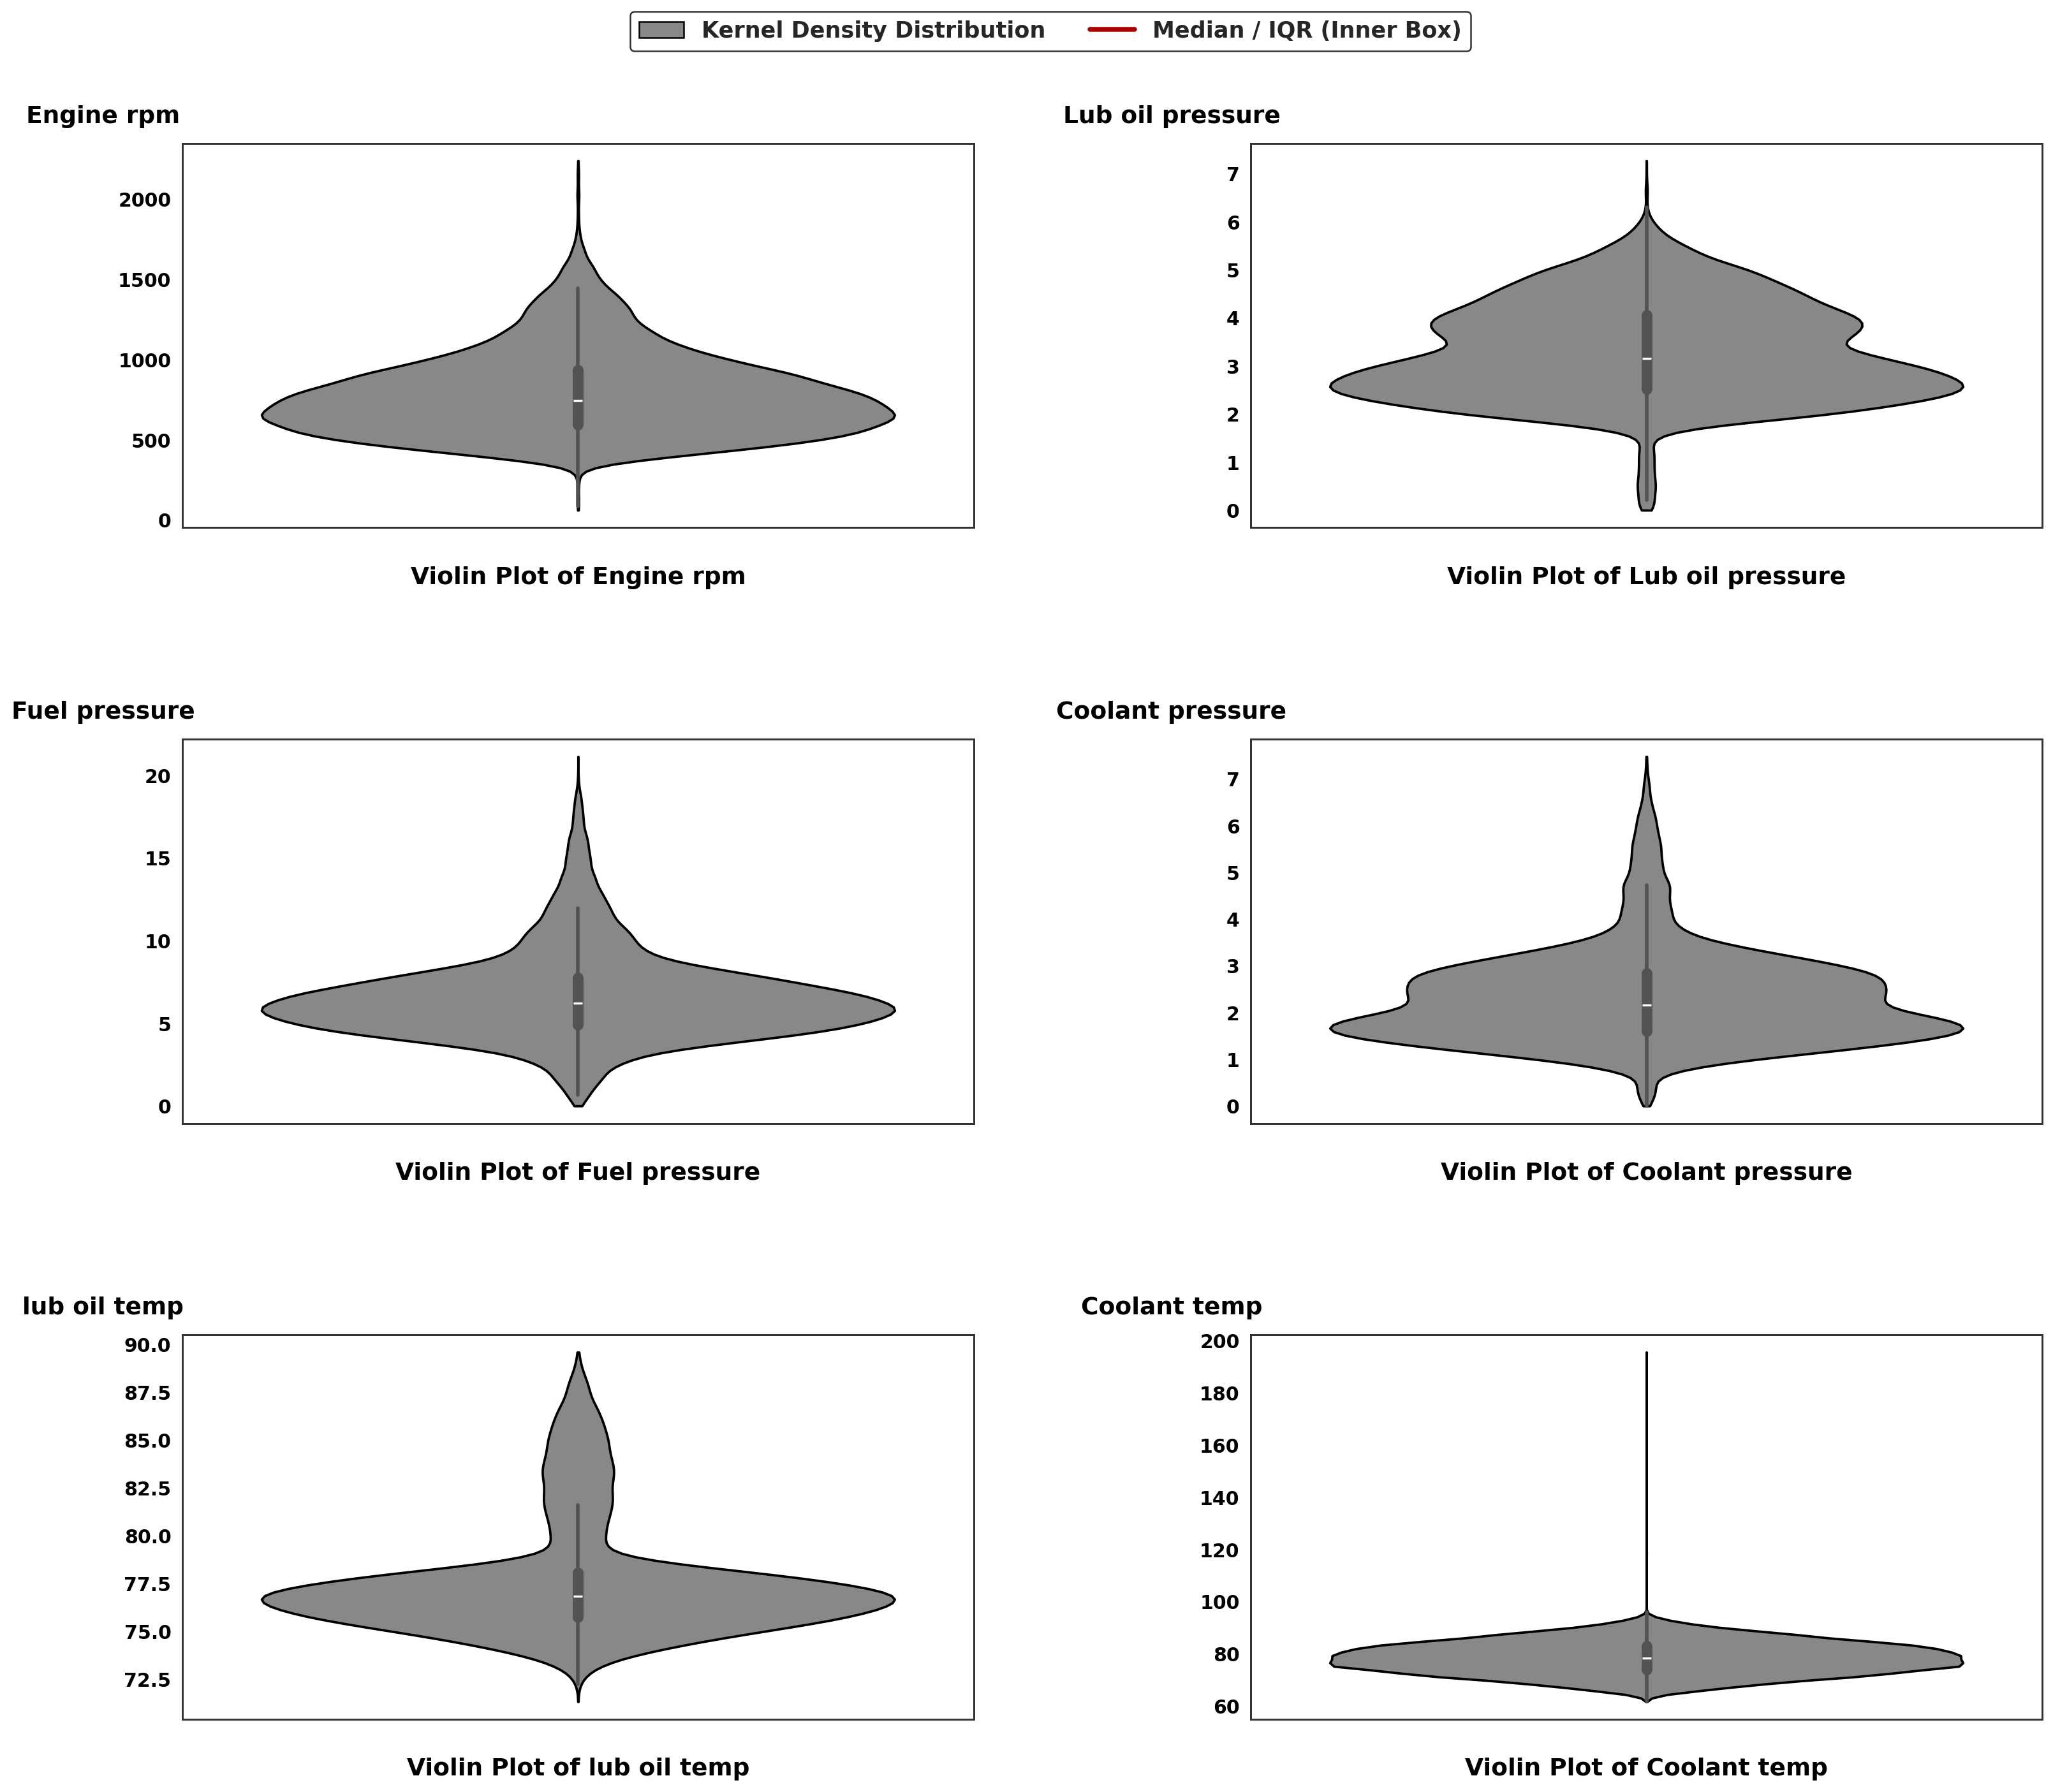


Insight: The violin plots combine a box plot with a kernel density estimate, providing a richer representation of the distribution of each feature. Wider sections indicate a higher concentration of observations, while narrower regions correspond to lower data density. The inner box summarises the median and interquartile range, facilitating the identification of skewness, multimodal distributions, and potential anomalous behaviour.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# High-quality display for Google Colab
plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Scientific style
sns.set_style("white")

# Layout
n_cols = 2
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5.2 * n_rows)
)

axes = axes.flatten()

# Style colours (same as your boxplots/histograms)
VIOLIN_COLOR = "#888888"
EDGE_COLOR = "#000000"
MEDIAN_COLOR = "#AA0000"
TEXT_COLOR = "#000000"
SPINE_COLOR = "#333333"

for i, column in enumerate(df.columns):

    data = df[column].dropna()

    # Violin plot
    sns.violinplot(
        y=data,
        ax=axes[i],
        color=VIOLIN_COLOR,
        linewidth=1.5,
        inner="box",      # Shows median and IQR inside
        cut=0
    )

    # Make violin borders black
    for collection in axes[i].collections:
        try:
            collection.set_edgecolor(EDGE_COLOR)
        except:
            pass

    # Titles
    axes[i].set_title("")

    axes[i].text(
        0.5,
        -0.1,
        f"Violin Plot of {column}",
        transform=axes[i].transAxes,
        ha="center",
        va="top",
        fontsize=15,
        fontweight="bold",
        color=TEXT_COLOR
    )

    # Horizontal y-label
    axes[i].set_ylabel(
        column,
        fontsize=15,
        fontweight="bold",
        rotation=0,
        color=TEXT_COLOR
    )

    axes[i].yaxis.set_label_coords(-0.10, 1.04)

    axes[i].grid(False)

    # Spine style
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(1.2)

    # Tick style
    axes[i].tick_params(
        axis="both",
        labelsize=12,
        colors=TEXT_COLOR,
        width=1
    )

    for tick in axes[i].get_xticklabels() + axes[i].get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(TEXT_COLOR)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_elements = [
    Patch(
        facecolor=VIOLIN_COLOR,
        edgecolor=EDGE_COLOR,
        label="Kernel Density Distribution"
    ),
    Line2D(
        [0], [0],
        color=MEDIAN_COLOR,
        lw=3,
        label="Median / IQR (Inner Box)"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=2,
    frameon=True,
    edgecolor="#333333",
    facecolor="white",
    framealpha=1,
    bbox_to_anchor=(0.5, 1.01),
    prop={"weight": "bold", "size": 14}
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.93,
    bottom=0.05,
    hspace=0.55,
    wspace=0.35
)

plt.show()

print(
    "\nInsight: The violin plots combine a box plot with a kernel density estimate, "
    "providing a richer representation of the distribution of each feature. Wider "
    "sections indicate a higher concentration of observations, while narrower regions "
    "correspond to lower data density. The inner box summarises the median and "
    "interquartile range, facilitating the identification of skewness, multimodal "
    "distributions, and potential anomalous behaviour."
)

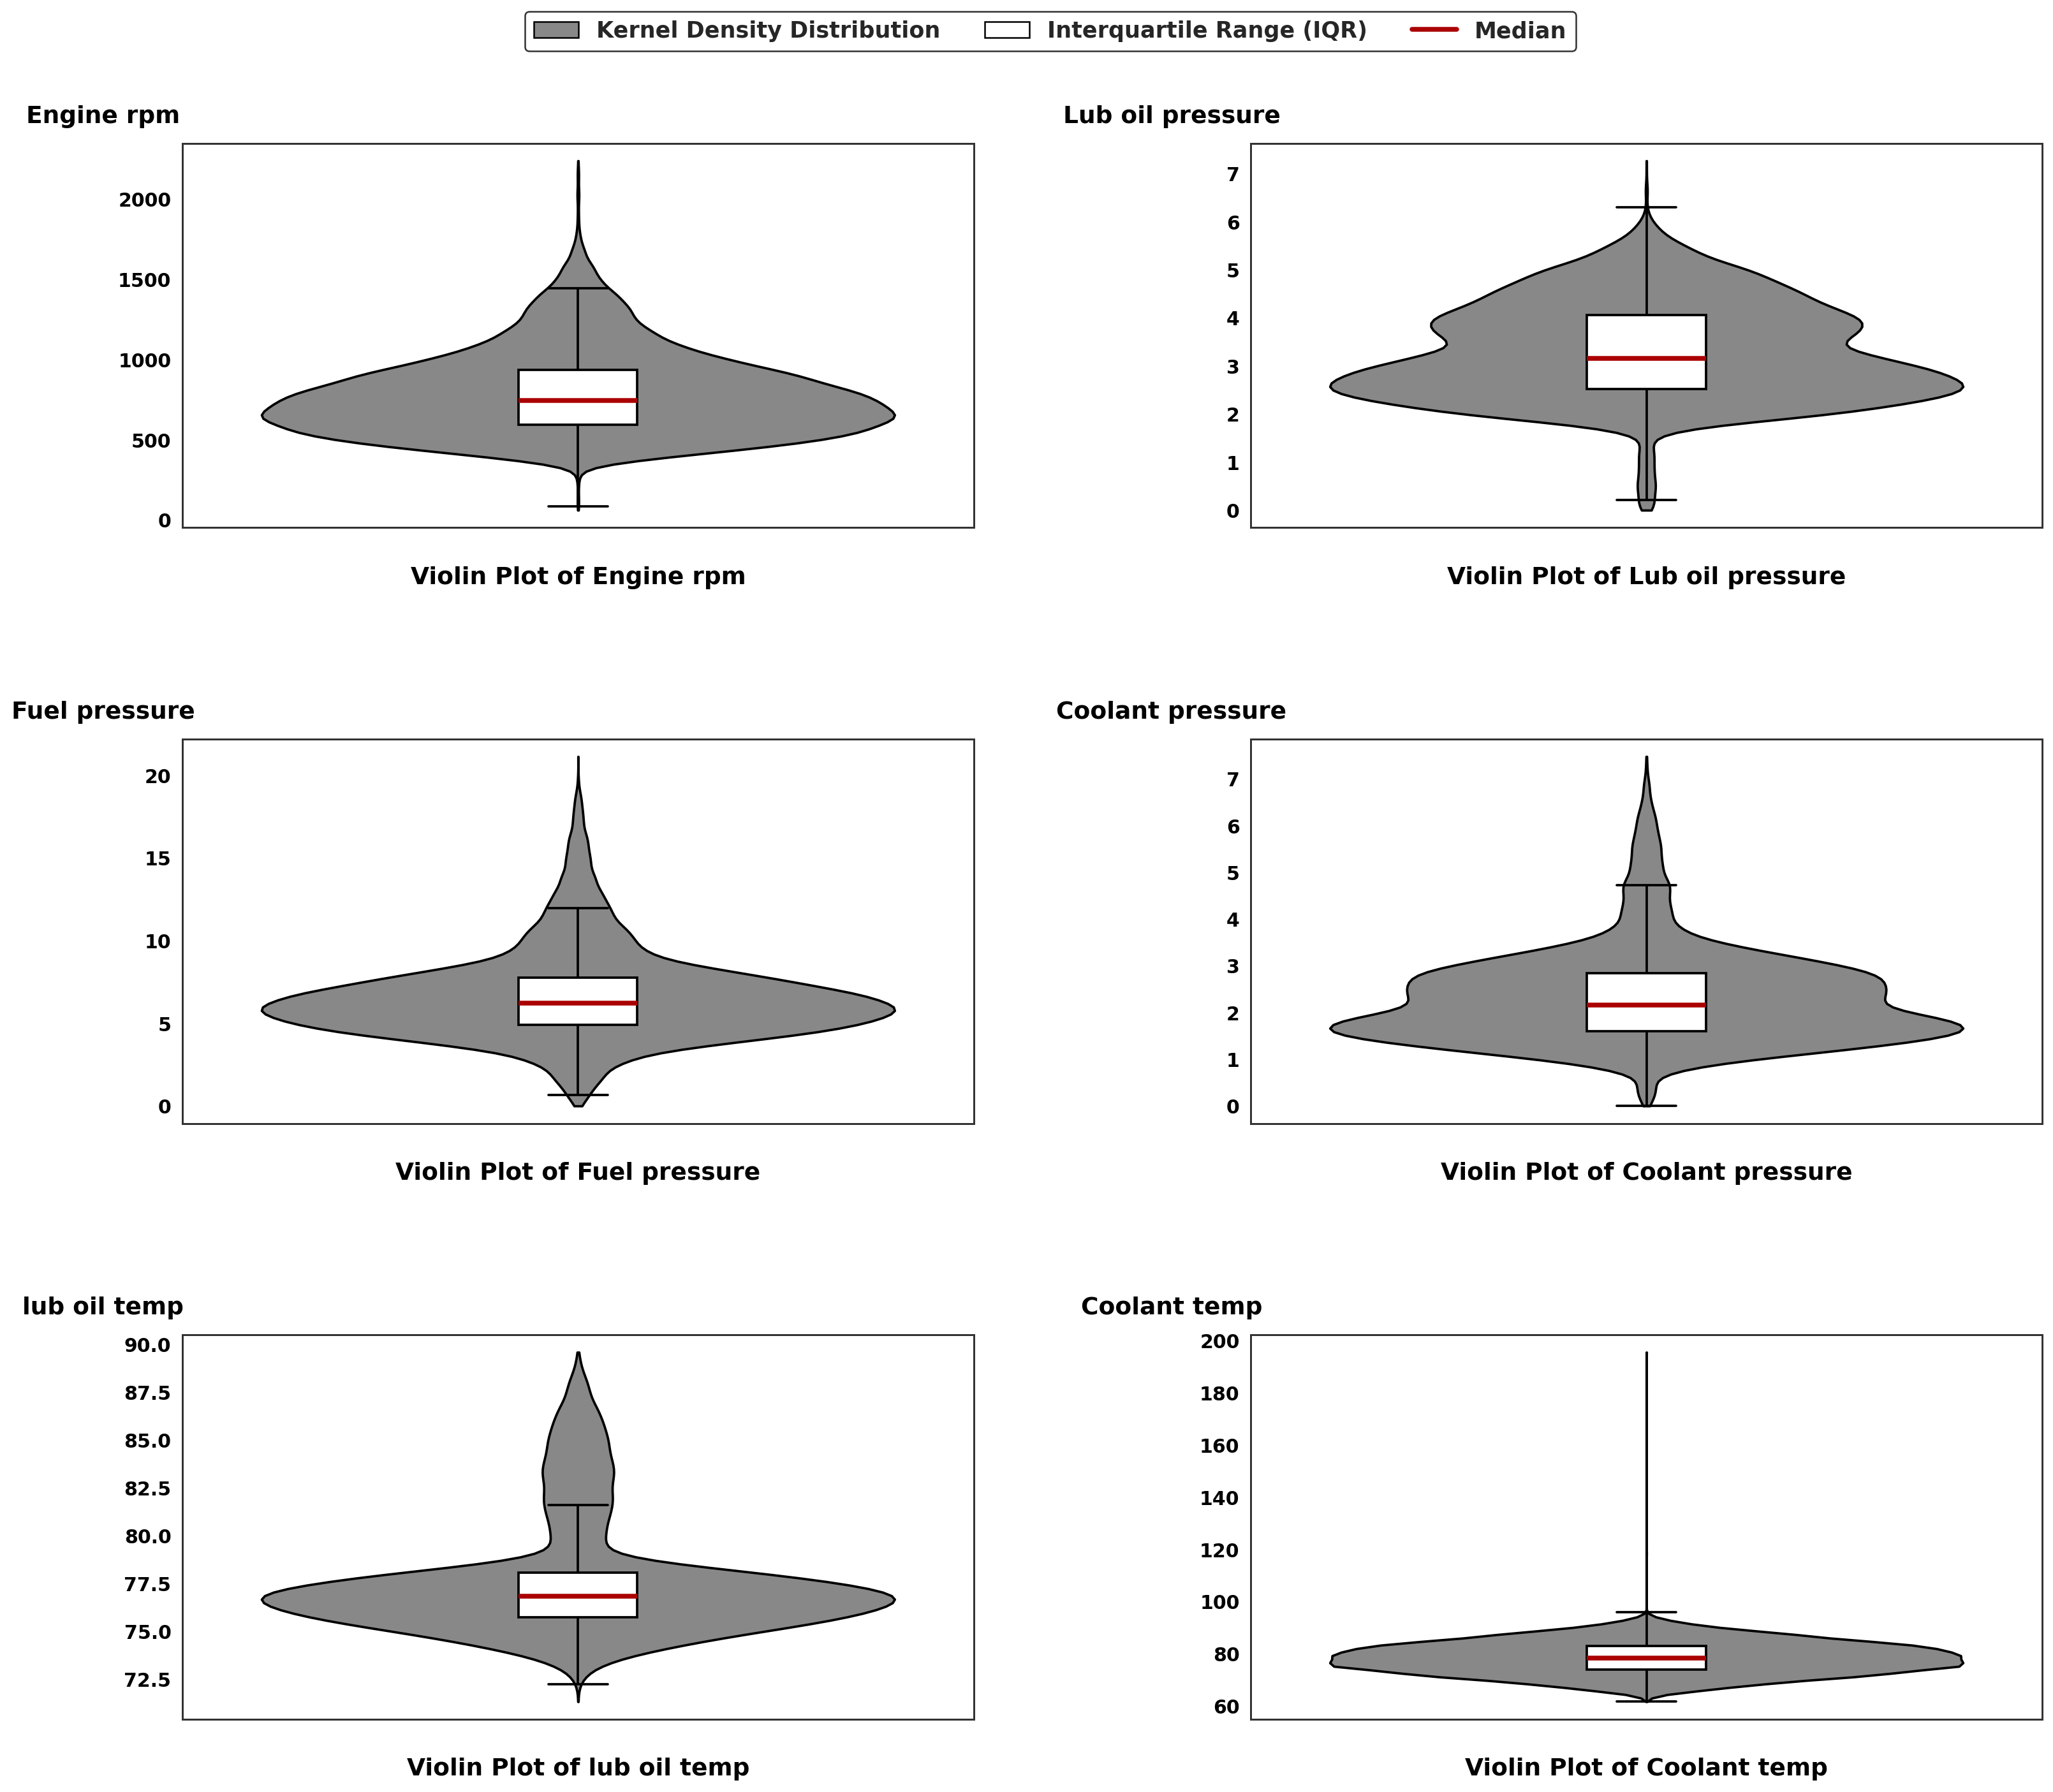


Insight: The violin plots combine a box plot with a kernel density estimate, providing a richer representation of the distribution of each feature. Wider sections indicate a higher concentration of observations, while narrower regions correspond to lower data density. The overlaid boxplot summarises the interquartile range, while the red horizontal line indicates the median, facilitating the identification of skewness, multimodal distributions, and potential anomalous behaviour.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# High-quality display for Google Colab
plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Scientific style
sns.set_style("white")

# Layout
n_cols = 2
n_rows = math.ceil(len(df.columns) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5.2 * n_rows)
)

axes = axes.flatten()

# Style colours
VIOLIN_COLOR = "#888888"
EDGE_COLOR = "#000000"
MEDIAN_COLOR = "#AA0000"
TEXT_COLOR = "#000000"
SPINE_COLOR = "#333333"

for i, column in enumerate(df.columns):

    data = df[column].dropna()

    # Violin plot
    sns.violinplot(
        y=data,
        ax=axes[i],
        color=VIOLIN_COLOR,
        linewidth=1.5,
        inner=None,      # We will add our own boxplot
        cut=0
    )

    # Make violin border black
    for collection in axes[i].collections:
        try:
            collection.set_edgecolor(EDGE_COLOR)
        except Exception:
            pass

    # Overlay boxplot with RED median
    sns.boxplot(
        y=data,
        ax=axes[i],
        width=0.15,
        showfliers=False,
        boxprops=dict(
            facecolor="white",
            edgecolor=EDGE_COLOR,
            linewidth=1.5
        ),
        whiskerprops=dict(
            color=EDGE_COLOR,
            linewidth=1.5
        ),
        capprops=dict(
            color=EDGE_COLOR,
            linewidth=1.5
        ),
        medianprops=dict(
            color=MEDIAN_COLOR,
            linewidth=3
        )
    )

    # Remove default title
    axes[i].set_title("")

    # Subtitle below plot
    axes[i].text(
        0.5,
        -0.1,
        f"Violin Plot of {column}",
        transform=axes[i].transAxes,
        ha="center",
        va="top",
        fontsize=15,
        fontweight="bold",
        color=TEXT_COLOR
    )

    # Horizontal y-label
    axes[i].set_ylabel(
        column,
        fontsize=15,
        fontweight="bold",
        rotation=0,
        color=TEXT_COLOR
    )

    axes[i].yaxis.set_label_coords(-0.10, 1.04)

    axes[i].grid(False)

    # Spine style
    for spine in axes[i].spines.values():
        spine.set_visible(True)
        spine.set_color(SPINE_COLOR)
        spine.set_linewidth(1.2)

    # Tick style
    axes[i].tick_params(
        axis="both",
        labelsize=12,
        colors=TEXT_COLOR,
        width=1
    )

    for tick in axes[i].get_xticklabels() + axes[i].get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color(TEXT_COLOR)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Legend
legend_elements = [
    Patch(
        facecolor=VIOLIN_COLOR,
        edgecolor=EDGE_COLOR,
        label="Kernel Density Distribution"
    ),
    Patch(
        facecolor="white",
        edgecolor=EDGE_COLOR,
        label="Interquartile Range (IQR)"
    ),
    Line2D(
        [0], [0],
        color=MEDIAN_COLOR,
        lw=3,
        label="Median"
    )
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    ncol=3,
    frameon=True,
    edgecolor="#333333",
    facecolor="white",
    framealpha=1,
    bbox_to_anchor=(0.5, 1.01),
    prop={"weight": "bold", "size": 14}
)

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.93,
    bottom=0.05,
    hspace=0.55,
    wspace=0.35
)

plt.show()

print(
    "\nInsight: The violin plots combine a box plot with a kernel density estimate, "
    "providing a richer representation of the distribution of each feature. Wider "
    "sections indicate a higher concentration of observations, while narrower regions "
    "correspond to lower data density. The overlaid boxplot summarises the interquartile "
    "range, while the red horizontal line indicates the median, facilitating the "
    "identification of skewness, multimodal distributions, and potential anomalous behaviour."
)

The violin plots complement the histogram and box plot analysis by revealing the underlying density of each feature. Several variables exhibit skewed or multimodal distributions with extended tails, indicating heterogeneous operating conditions and supporting the use of anomaly detection methods that can accommodate non-normal data and extreme observations.

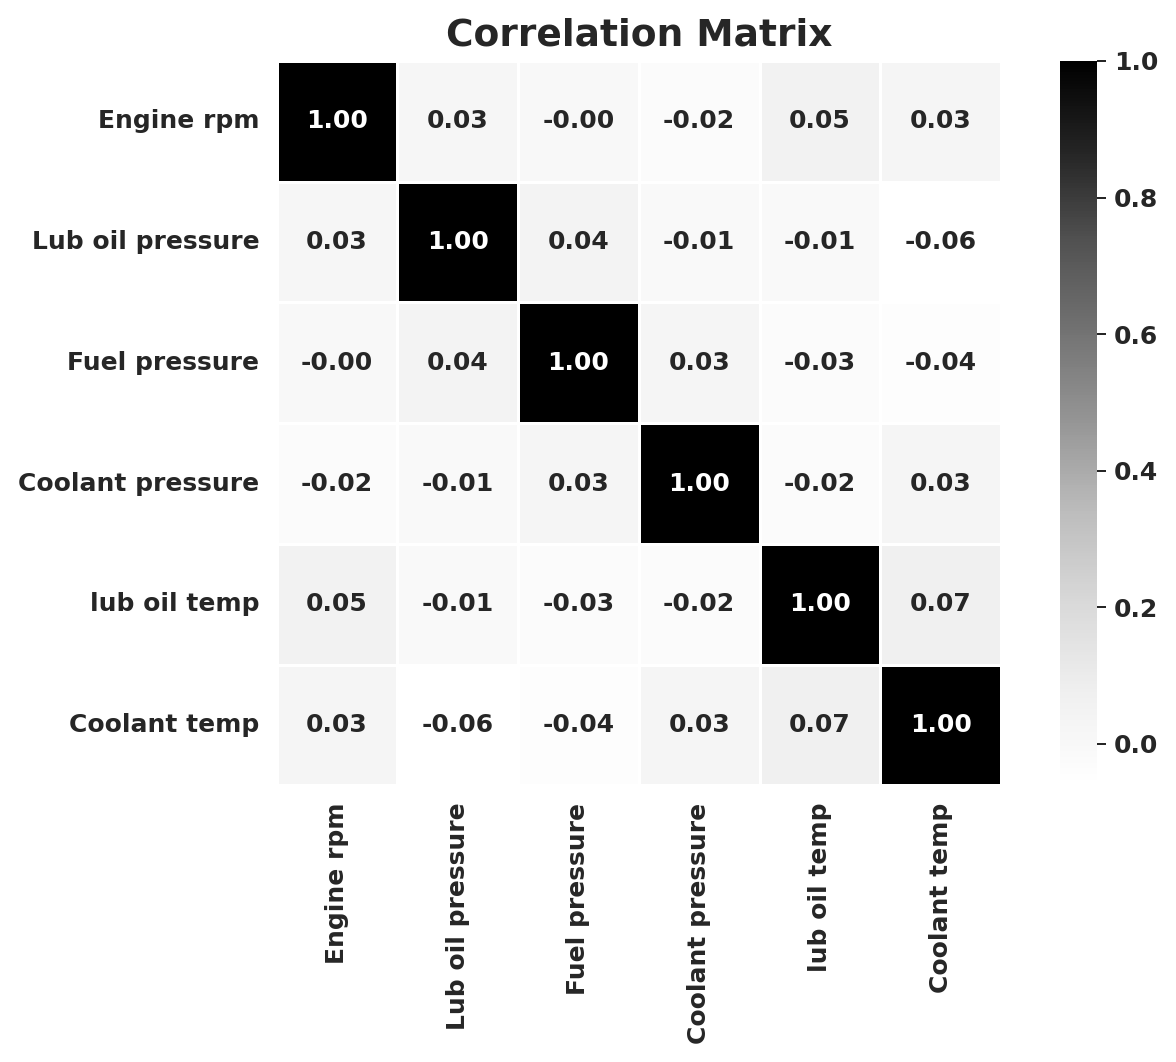

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    cmap="Greys",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

The correlation matrix indicates **negligible linear relationships between the variables**, with all correlation coefficients close to zero. This suggests that the features provide **complementary information** and that anomaly detection should rely on multivariate patterns rather than simple linear dependencies.

# 5. Perform anomaly detection with a statistical method and identify possible anomalies. Specifically:
  
  >## 5.1. Use the interquartile range (IQR) method to identify outliers for each feature.

In [14]:
import pandas as pd

# Store results
results = []

print("="*70)
print("ANOMALY DETECTION USING THE IQR METHOD")
print("="*70)

for column in df.columns:

    # Calculate quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Bounds
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Outliers
    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    results.append({
        "Feature": column,
        "Q1": round(Q1,3),
        "Q3": round(Q3,3),
        "IQR": round(IQR,3),
        "Lower Bound": round(lower,3),
        "Upper Bound": round(upper,3),
        "Outliers": len(outliers),
        "Percentage (%)": round(100*len(outliers)/len(df),2)
    })

    print(f"\n{column}")
    print(f"Q1: {Q1:.3f}")
    print(f"Q3: {Q3:.3f}")
    print(f"IQR: {IQR:.3f}")
    print(f"Lower bound: {lower:.3f}")
    print(f"Upper bound: {upper:.3f}")
    print(f"Outliers detected: {len(outliers)} ({100*len(outliers)/len(df):.2f}%)")

# Summary table
results = pd.DataFrame(results)

print("\n")
display(results)

ANOMALY DETECTION USING THE IQR METHOD

Engine rpm
Q1: 593.000
Q3: 934.000
IQR: 341.000
Lower bound: 81.500
Upper bound: 1445.500
Outliers detected: 464 (2.38%)

Lub oil pressure
Q1: 2.519
Q3: 4.055
IQR: 1.536
Lower bound: 0.214
Upper bound: 6.360
Outliers detected: 66 (0.34%)

Fuel pressure
Q1: 4.917
Q3: 7.745
IQR: 2.828
Lower bound: 0.675
Upper bound: 11.987
Outliers detected: 1135 (5.81%)

Coolant pressure
Q1: 1.600
Q3: 2.849
IQR: 1.248
Lower bound: -0.272
Upper bound: 4.721
Outliers detected: 785 (4.02%)

lub oil temp
Q1: 75.726
Q3: 78.072
IQR: 2.346
Lower bound: 72.207
Upper bound: 81.590
Outliers detected: 2617 (13.40%)

Coolant temp
Q1: 73.895
Q3: 82.915
IQR: 9.020
Lower bound: 60.365
Upper bound: 96.445
Outliers detected: 2 (0.01%)




,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Percentage (%)
0,Engine rpm,593.000,934.000,341.000,81.500,1445.500,464,2.38
1,Lub oil pressure,2.519,4.055,1.536,0.214,6.360,66,0.34
2,Fuel pressure,4.917,7.745,2.828,0.675,11.987,1135,5.81
3,Coolant pressure,1.600,2.849,1.248,-0.272,4.721,785,4.02
4,lub oil temp,75.726,78.072,2.346,72.207,81.590,2617,13.40
5,Coolant temp,73.895,82.915,9.020,60.365,96.445,2,0.01


The IQR method identified different proportions of outliers across the engine sensor variables. **Most features exhibited anomaly rates below 6%,** which is broadly consistent with the **expected rarity** of anomalous observations in engine monitoring data.

In contrast, **'lubrication oil temperature' showed a substantially higher outlier rate (13.40%),** suggesting that its distribution is not well represented by the IQR assumptions and may reflect **multimodal operating conditions** rather than genuine anomalies. Conversely, coolant temperature exhibited only two outliers (0.01%), indicating highly stable behaviour.

The 13.4% of lubrication oil temperature observations ought not to be removed based solely on the IQR method. Yet, it is important to mention that this highlights a **limitation of univariate statistical methods** and motivates the use of **multivariate machine learning techniques (Isolation Forest and One-Class SVM)** later in the project, which can better distinguish true anomalies from normal operating regimes.

  >## 5.2. Create a new column (corresponding to each feature) that will indicate (in binary – 0,1) if the value of that feature is an outlier as per IQR calculations.

In [15]:
import pandas as pd

# Create a copy of the original dataset
df_iqr = df.copy()

# Store IQR results
iqr_summary = []

# Apply IQR anomaly detection to each feature
for column in df.columns:

    # Calculate Q1, Q3 and IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Create binary outlier column
    outlier_column = column + "_outlier"

    df_iqr[outlier_column] = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).astype(int)

    # Store summary results
    outlier_count = df_iqr[outlier_column].sum()
    outlier_percentage = (outlier_count / len(df_iqr)) * 100

    iqr_summary.append({
        "Feature": column,
        "Q1": round(Q1, 3),
        "Q3": round(Q3, 3),
        "IQR": round(IQR, 3),
        "Lower Bound": round(lower_bound, 3),
        "Upper Bound": round(upper_bound, 3),
        "Outliers": outlier_count,
        "Percentage (%)": round(outlier_percentage, 2)
    })

# Create a global anomaly column
outlier_columns = [col for col in df_iqr.columns if col.endswith("_outlier")]

df_iqr["Any_Anomaly"] = (
    df_iqr[outlier_columns].sum(axis=1) > 0
).astype(int)

# Create summary table
iqr_summary = pd.DataFrame(iqr_summary)

# Display results
display(df_iqr.head())
display(iqr_summary)

print("Total observations:", len(df_iqr))
print("Total anomalous observations:", df_iqr["Any_Anomaly"].sum())
print("Percentage of anomalous observations:", round(df_iqr["Any_Anomaly"].mean() * 100, 2), "%")

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine rpm_outlier,Lub oil pressure_outlier,Fuel pressure_outlier,Coolant pressure_outlier,lub oil temp_outlier,Coolant temp_outlier,Any_Anomaly
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,0,0,0,0,0,0,0
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,0,0,0,1,0,0,1
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,0,0,0,0,1,0,1
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,0,0,0,0,0,0,0
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,0,0,0,0,0,0,0


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Percentage (%)
0,Engine rpm,593.000,934.000,341.000,81.500,1445.500,464,2.38
1,Lub oil pressure,2.519,4.055,1.536,0.214,6.360,66,0.34
2,Fuel pressure,4.917,7.745,2.828,0.675,11.987,1135,5.81
3,Coolant pressure,1.600,2.849,1.248,-0.272,4.721,785,4.02
4,lub oil temp,75.726,78.072,2.346,72.207,81.590,2617,13.40
5,Coolant temp,73.895,82.915,9.020,60.365,96.445,2,0.01


Total observations: 19535
Total anomalous observations: 4636
Percentage of anomalous observations: 23.73 %


The Interquartile Range (IQR) method was applied independently to each engine sensor feature in order to identify potential outliers. For each variable, the first quartile (Q1), third quartile (Q3), and IQR were calculated. Observations below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR were classified as potential anomalies.

A new binary outlier column was created for each feature, where 0 indicates a normal value and 1 indicates an outlier according to the IQR rule. In addition, a global anomaly column was created to identify observations where at least one feature was flagged as anomalous.

This approach provides a simple statistical baseline for anomaly detection and helps identify which engine sensor variables contain the highest number of extreme values. However, since the IQR method is applied independently to each feature, it may not capture multivariate anomalies where individual values appear normal but their combined behaviour is unusual.

  >## 5.3. Use IQR to identify the number of features that must simultaneously be in outlier condition, in order for a sample to be classified as an outlier, such that the total percentage of samples identified as outliers falls within the 1-5% range.

**Comment**:

The overall anomality percentage is of 23.73 % if each anomality in each variable is an overall anomality. This number steps considerably far from standard anomality ranges, being 1-5 % the usual gap.

That said: it is interesting to analyse this figure and the actionable information that is bringing up - is each variable enough to flag an anomaly by itself or a combination of variables and an analysis is needed to do so.

In this point, the question is:
> How many features must simultaneously be outliers (2, 3, 4, …) so that the overall anomaly rate is between 1% and 5%?

In [16]:
# Binary outlier columns
outlier_columns = [col for col in df_iqr.columns if col.endswith("_outlier")]

# Count how many features are outliers for each observation
df_iqr["Outlier_Count"] = df_iqr[outlier_columns].sum(axis=1)

print("="*60)
print("IQR MULTIVARIATE ANOMALY ANALYSIS")
print("="*60)

for threshold in range(1, len(outlier_columns)+1):

    anomalies = (df_iqr["Outlier_Count"] >= threshold).sum()
    percentage = anomalies / len(df_iqr) * 100

    print(
        f"At least {threshold} feature(s) in outlier condition: "
        f"{anomalies} samples ({percentage:.2f}%)"
    )

IQR MULTIVARIATE ANOMALY ANALYSIS
At least 1 feature(s) in outlier condition: 4636 samples (23.73%)
At least 2 feature(s) in outlier condition: 422 samples (2.16%)
At least 3 feature(s) in outlier condition: 11 samples (0.06%)
At least 4 feature(s) in outlier condition: 0 samples (0.00%)
At least 5 feature(s) in outlier condition: 0 samples (0.00%)
At least 6 feature(s) in outlier condition: 0 samples (0.00%)


To extend the univariate IQR analysis, the number of features simultaneously identified as outliers was computed for each observation. Different thresholds were evaluated by requiring at least 1, 2, 3, or more features to be in an outlier condition before classifying an observation as anomalous.

The results showed that considering at least one outlying feature classified 23.73% of the observations as anomalies, which is considerably higher than the expected anomaly rate of 1–5%. Requiring at least three simultaneous outlying features reduced the anomaly rate to only 0.06%, which is overly restrictive.

Conversely, requiring at least two features to be simultaneously in an outlier condition identified 422 observations (2.16% of the dataset) as anomalies. This percentage falls within the expected range for rare anomalous engine behaviour and therefore represents the most appropriate threshold for classifying samples as anomalous using the IQR method.

This analysis considers only the **number of features simultaneously identified as outliers**, without accounting for the **specific combinations of outlying features**. Consequently, observations exhibiting different combinations of anomalous variables are treated equally, even though certain feature combinations may be more indicative of abnormal engine behaviour than others. Considering these interactions could provide a more informative criterion for anomaly detection.


In [17]:
outlier_cols = [c for c in df_iqr.columns if c.endswith("_outlier")]

# Create a string representing the combination of outlier features
combination = (
    df_iqr[outlier_cols]
    .apply(lambda row: tuple(df.columns[row == 1]), axis=1)
)

combination.value_counts().head(15)

,count
(),14899
"(lub oil temp,)",2280
"(Fuel pressure,)",918
"(Coolant pressure,)",614
"(Engine rpm,)",352
"(Fuel pressure, lub oil temp)",143
"(Coolant pressure, lub oil temp)",107
"(Engine rpm, lub oil temp)",68
"(Lub oil pressure,)",48
"(Fuel pressure, Coolant pressure)",38


Based on the IQR analysis, a sample is classified as anomalous when **at least two features are simultaneously identified as outliers**. This criterion detects **422 observations (2.16%)**, satisfying the expected anomaly rate of **1–5%** while reducing the number of false positives associated with isolated outlying measurements.


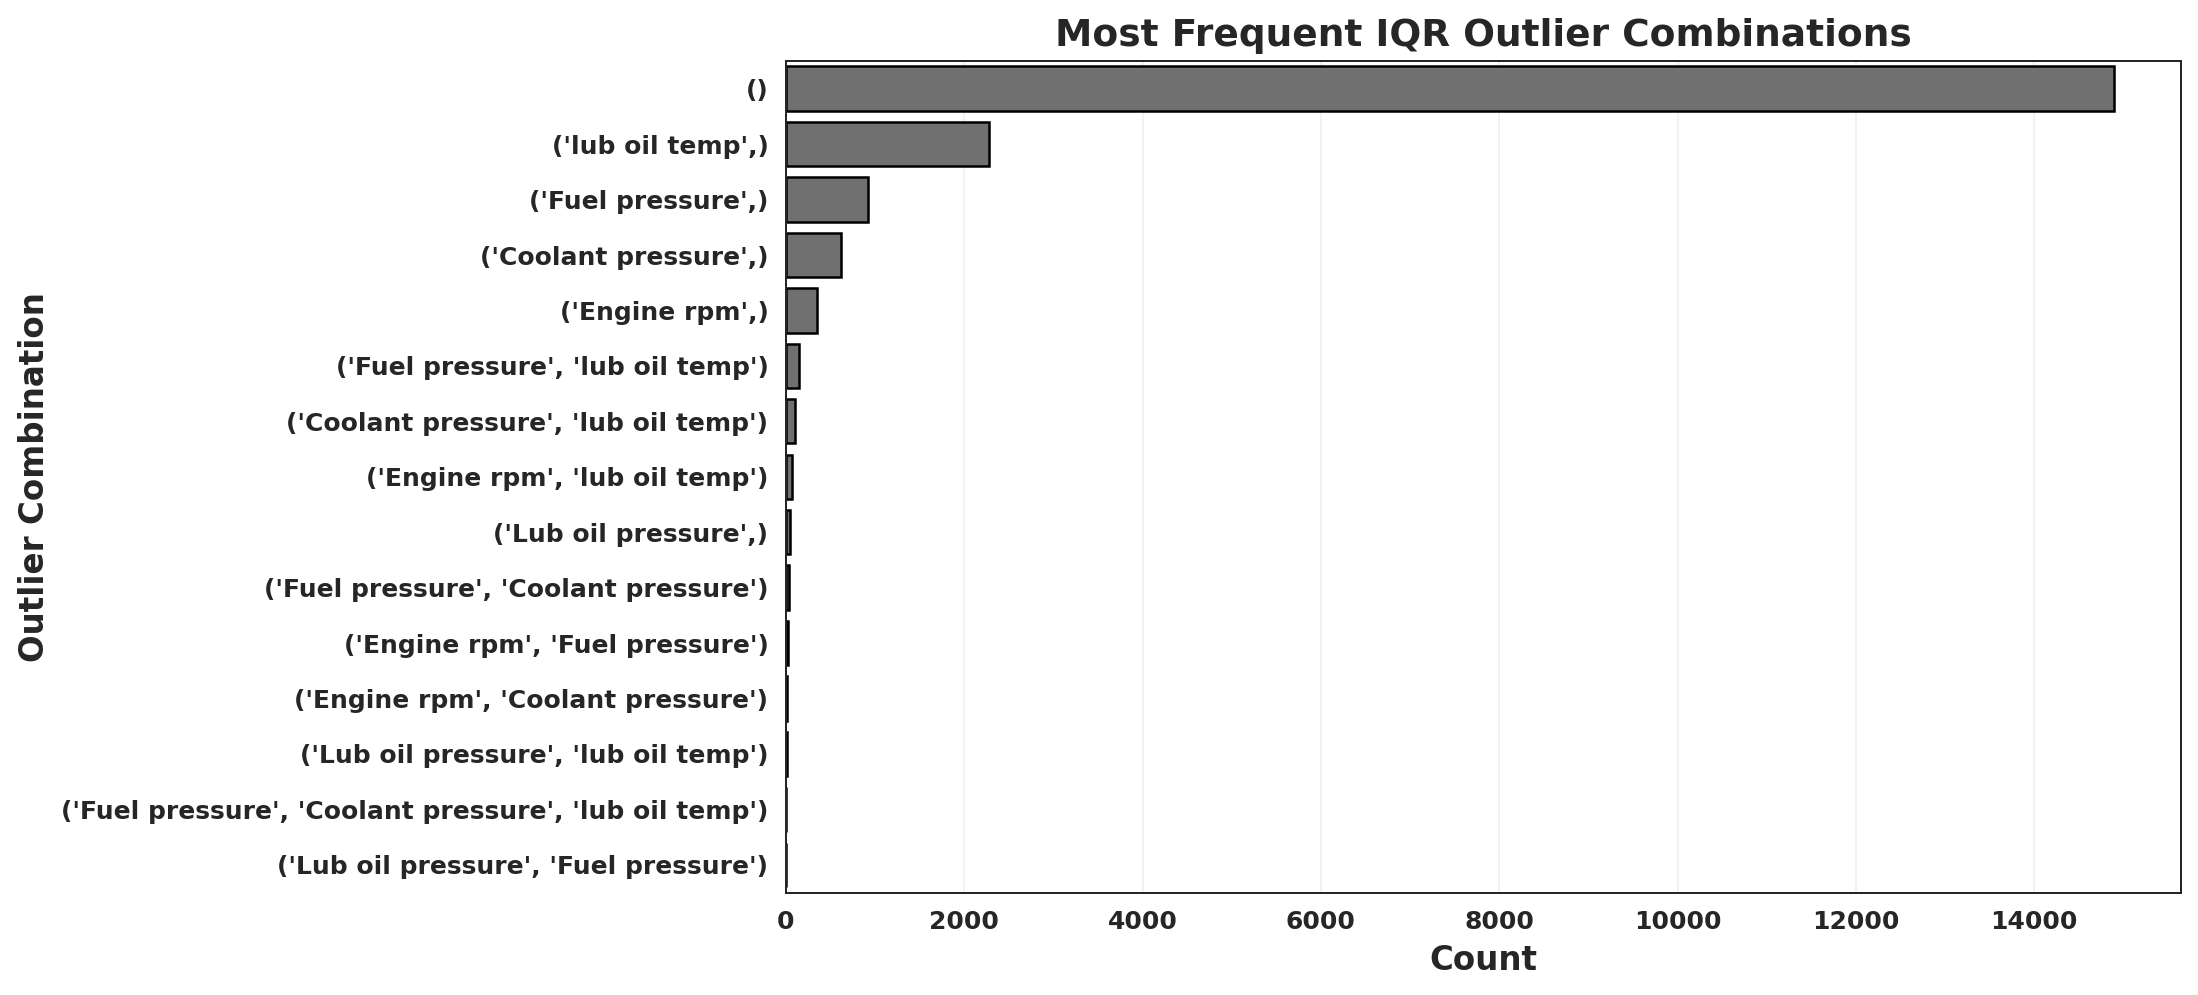

In [18]:
comb_counts = combination.value_counts().head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x=comb_counts.values,
    y=comb_counts.index.astype(str),
    color="#707070",
    edgecolor="black"
)

plt.xlabel("Count", fontsize=13, fontweight="bold")
plt.ylabel("Outlier Combination", fontsize=13, fontweight="bold")
plt.title(
    "Most Frequent IQR Outlier Combinations",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.25)
plt.show()

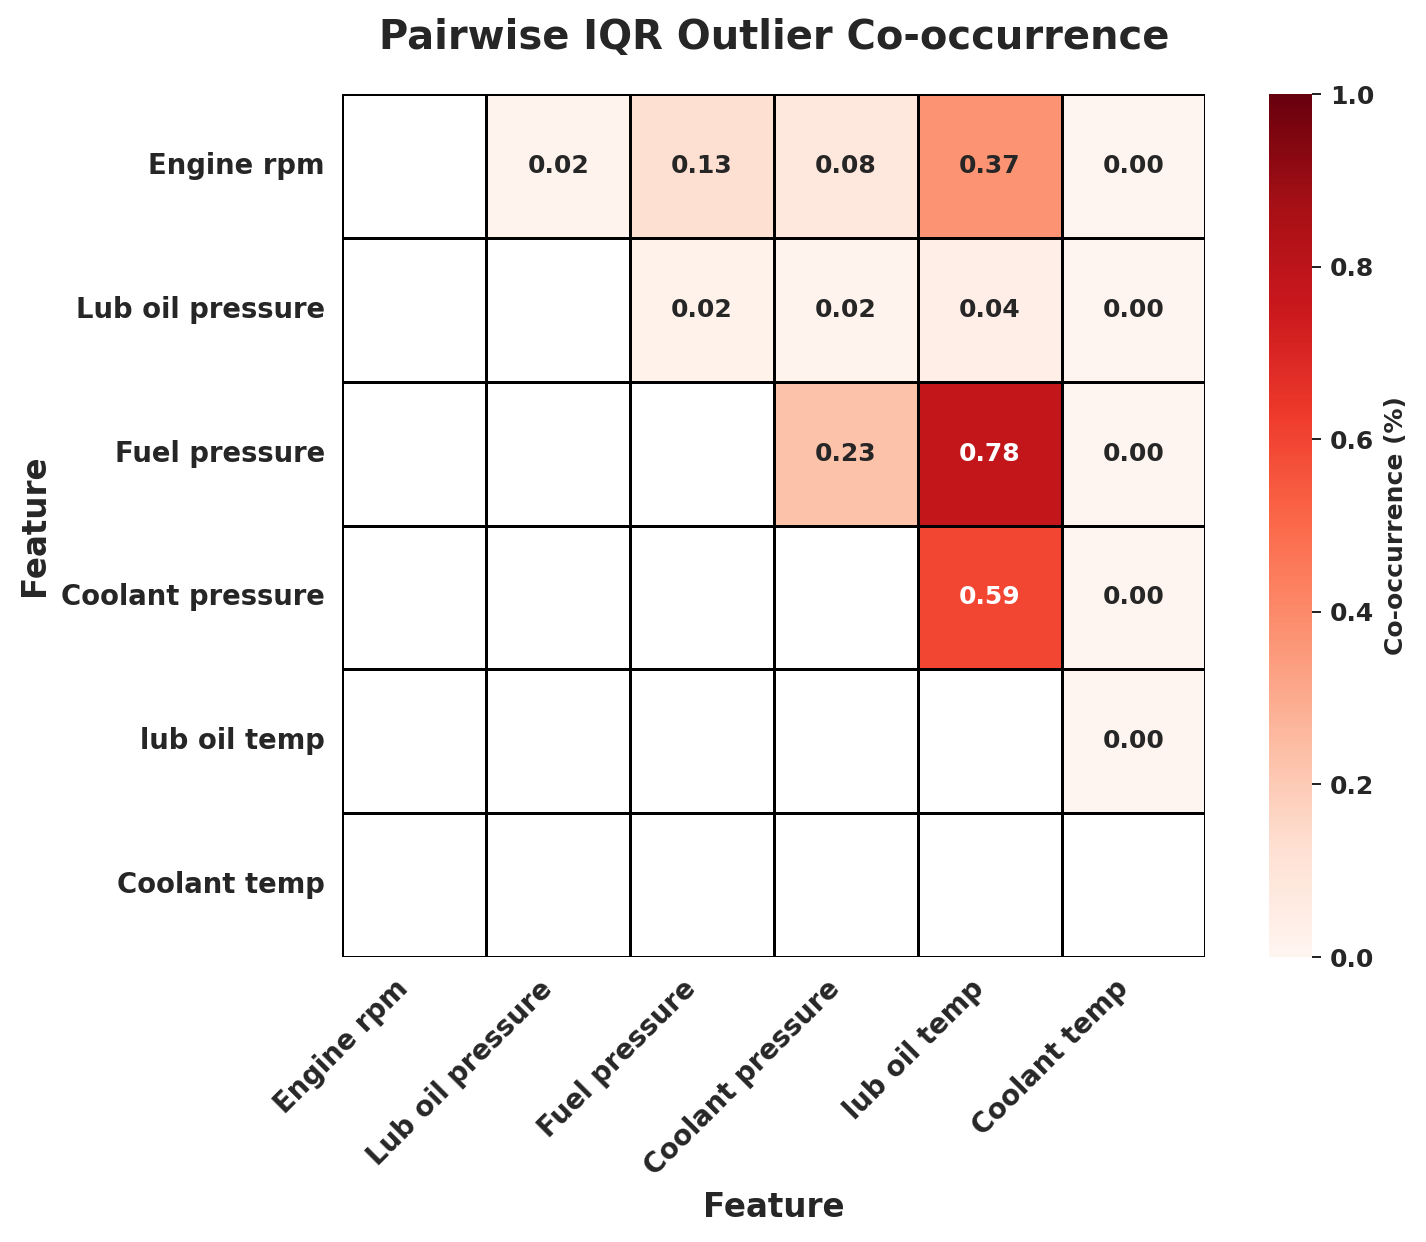

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Binary outlier columns
outlier_cols = [c for c in df_iqr.columns if c.endswith("_outlier")]

# Clean feature names
feature_names = [c.replace("_outlier", "") for c in outlier_cols]

# Pairwise co-occurrence matrix (% of total samples)
co_occurrence = df_iqr[outlier_cols].T.dot(df_iqr[outlier_cols])
co_occurrence_pct = co_occurrence / len(df_iqr) * 100

co_occurrence_pct.index = feature_names
co_occurrence_pct.columns = feature_names

# Hide the diagonal and lower triangle
mask = np.tril(np.ones_like(co_occurrence_pct, dtype=bool))

plt.figure(figsize=(9,7))

sns.heatmap(
    co_occurrence_pct,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    linewidths=1,
    linecolor="black",
    square=True,
    vmin=0,
    vmax=1,
    cbar_kws={"label":"Co-occurrence (%)"}
)

plt.title(
    "Pairwise IQR Outlier Co-occurrence",
    fontsize=16,
    fontweight="bold",
    pad=18
)

plt.xlabel("Feature", fontsize=13, fontweight="bold")
plt.ylabel("Feature", fontsize=13, fontweight="bold")

plt.xticks(rotation=45, ha="right", fontsize=11, fontweight="bold")
plt.yticks(rotation=0, fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

### Pairwise IQR Outlier Co-occurrence

The heatmap illustrates the percentage of observations in which two features are simultaneously identified as outliers according to the IQR criterion. Darker colours indicate stronger co-occurrence between anomalous sensor readings.

The strongest pairwise relationships involve **lubrication oil temperature**, particularly in combination with **Fuel pressure (0.78%)** and **Coolant pressure (0.59%)**, suggesting that abnormal lubrication oil temperature frequently occurs alongside anomalies in these pressure sensors. In contrast, **Coolant temperature** exhibits almost no simultaneous outlier behaviour with the remaining variables, indicating a highly stable operating pattern.

These results suggest that the **specific combination of anomalous features may provide additional information beyond simply counting the number of outlying variables**. Consequently, multivariate anomaly detection methods that consider feature interactions may offer a more informative representation of abnormal engine behaviour than independent univariate statistical rules.

  >## 5.4. Record your thoughts and observations.
  

The IQR method provides a simple and interpretable statistical approach for detecting potential anomalies in individual engine sensor variables. However, the results indicate that many observations are identified as outliers in only a single feature, particularly **lubrication oil temperature**, suggesting that isolated outliers may reflect natural variability rather than abnormal engine behaviour. Requiring at least **two simultaneous outlying features** produces an anomaly rate consistent with the expected 1–5% range and provides a more reliable criterion for identifying potentially anomalous operating conditions. This analysis also highlights the limitations of univariate methods and motivates the use of multivariate machine learning techniques in the following stages of the project.


There is an interesting point to highlight: the typical co-occureence is not between to variables associated to the same liquid, but between lub temperature and coolant/fuel pressure, even with engine rpm. This might pinpoint the temperature of the lubricant liquid as a paramount variable to avoid anomalies.

# 6. Perform anomaly detection with ML models:

  - Using one-class SVM,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.
  - Using Isolation Forest,
    - identify possible anomalies
    - visualise the output in 2D after performing PCA and ensure the outliers are in a different colour
    - apply different combinations of parameter settings to improve the model's outlier predictions to the expected 1-5%
    - record your insights about the use of this method.

## OCSVM

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA

# ==========================
# Standardise the features
# ==========================

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================
# One-Class SVM model
# ==========================

ocsvm = OneClassSVM(
    kernel="rbf",
    nu=0.02,          # expected anomaly proportion (adjust later)
    gamma="scale"     # 0.142857
)

predictions = ocsvm.fit_predict(X_scaled)

# Convert predictions to binary labels
# 1 = anomaly, 0 = normal

df["OneClassSVM_Anomaly"] = (predictions == -1).astype(int)

# Percentage of anomalies

n_anomalies = df["OneClassSVM_Anomaly"].sum()
percentage = 100 * n_anomalies / len(df)

print("="*60)
print("ONE-CLASS SVM RESULTS")
print("="*60)
print(f"Anomalies detected: {n_anomalies}")
print(f"Percentage: {percentage:.2f}%")

print(f"Gamma (scale) = {ocsvm._gamma:.6f}")

ONE-CLASS SVM RESULTS
Anomalies detected: 400
Percentage: 2.05%
Gamma (scale) = 0.166667


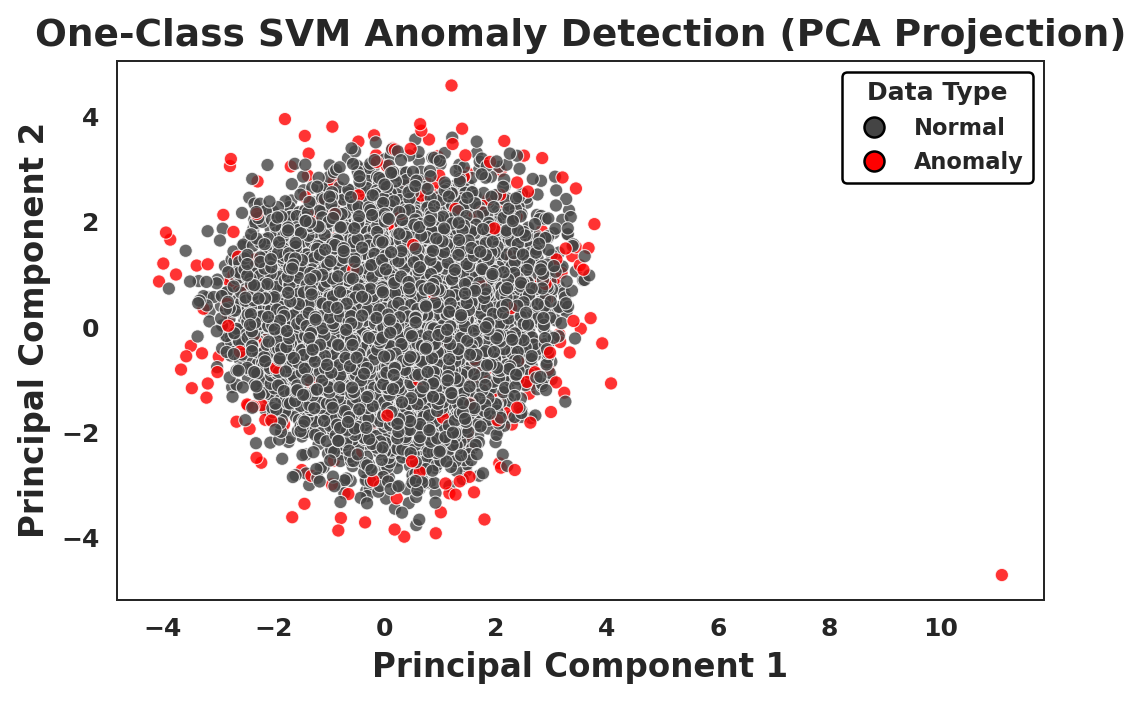

In [21]:
# ==========================
# PCA for visualization
# ==========================

from matplotlib.lines import Line2D

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Anomaly": df["OneClassSVM_Anomaly"]
})

plt.figure(figsize=(6, 4))

ax = sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Anomaly",
    palette={
        0: "#444444",
        1: "#FF0000"
    },
    s=28,
    alpha=0.8,
    legend=False
)

plt.title(
    "One-Class SVM Anomaly Detection (PCA Projection)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Principal Component 2",
    fontsize=13,
    fontweight="bold"
)

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Normal",
        markerfacecolor="#444444",
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Anomaly",
        markerfacecolor="#FF0000",
        markeredgecolor="black",
        markersize=8
    )
]

plt.legend(
    handles=legend_elements,
    title="Data Type",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=9,
    title_fontsize=10
)

plt.grid(False)
plt.tight_layout()
plt.show()

### Nu and Gamma variation analysis

In [22]:
for nu in [0.01,0.02,0.03,0.04,0.05]:

    model = OneClassSVM(
        kernel="rbf",
        nu=nu,
        gamma="scale"
    )

    pred = model.fit_predict(X_scaled)

    anomalies = (pred==-1).sum()

    print(
        f"nu={nu:.2f} --> "
        f"{100*anomalies/len(X_scaled):.2f}% anomalies"
    )

nu=0.01 --> 1.01% anomalies
nu=0.02 --> 2.05% anomalies
nu=0.03 --> 2.99% anomalies
nu=0.04 --> 4.02% anomalies
nu=0.05 --> 5.00% anomalies


If none produce 1–5%, then gamma is tuned too:

In [23]:
for gamma in [0.01,0.05,0.1,"scale","auto"]:

    model = OneClassSVM(
        kernel="rbf",
        nu=0.02,
        gamma=gamma
    )

    pred = model.fit_predict(X_scaled)

    anomalies = (pred==-1).sum()

    print(
        f"gamma={gamma} --> "
        f"{100*anomalies/len(X_scaled):.2f}% anomalies"
    )

gamma=0.01 --> 2.00% anomalies
gamma=0.05 --> 2.02% anomalies
gamma=0.1 --> 2.01% anomalies
gamma=scale --> 2.05% anomalies
gamma=auto --> 2.05% anomalies


The parameter `nu` primarily controls the expected proportion of anomalies detected by the One-Class SVM model. As observed, increasing `nu` led to a higher percentage of observations being classified as anomalous.

In contrast, `gamma` controls the flexibility of the RBF kernel and therefore the complexity of the decision boundary. Higher values of `gamma` may lead to overfitting by creating highly irregular boundaries around the training data, whereas lower values produce smoother decision regions. For this dataset, varying `gamma` had little effect on the anomaly rate, indicating that the model is relatively robust to this parameter within the tested range.

## IF

Step 1: Parameter tuning

In [24]:
for contamination in [0.01,0.02,0.03,0.04,0.05]:

    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=42
    )

    pred = model.fit_predict(X_scaled)

    anomalies = (pred == -1).sum()

    print(
        f"contamination={contamination:.2f} --> "
        f"{100*anomalies/len(X_scaled):.2f}% anomalies"
    )

NameError: name 'IsolationForest' is not defined

### Hyperparameter Selection

The `contamination` parameter was evaluated using values between **0.01** and **0.05**, corresponding to anomaly rates between **1%** and **5%**. As expected, the proportion of detected anomalies closely matched the specified contamination value, since this parameter directly controls the expected fraction of outliers in the dataset.

A value of **`contamination = 0.02`** was selected, resulting in approximately **2%** of the observations being classified as anomalous. This value falls within the expected anomaly range and provides consistency with the anomaly rates obtained using the IQR method (2.16%) and One-Class SVM (2.05%).

Step 2: Number of trees tuning



In [ ]:
for trees in [50, 100, 200, 300]:

    model = IsolationForest(
        n_estimators=trees,
        contamination=0.02,
        random_state=42
    )

    pred = model.fit_predict(X_scaled)

    anomalies = (pred == -1).sum()

    print(
        f"n_estimators={trees} --> "
        f"{100*anomalies/len(X_scaled):.2f}% anomalies"
    )

### Hyperparameter Selection

Two hyperparameters were evaluated for the Isolation Forest model: `contamination` and `n_estimators`.

The `contamination` parameter directly controls the expected proportion of anomalies and was tested using values between **0.01** and **0.05**. A value of **0.02** was selected because it identifies approximately **2%** of the observations as anomalous, which falls within the expected **1–5%** anomaly range.

The number of trees (`n_estimators`) was also evaluated using **50, 100, 200, and 300** trees. The results remained unchanged, with all configurations detecting **2.00%** anomalies. This indicates that the model is stable with respect to the number of trees and that increasing `n_estimators` does not improve anomaly detection for this dataset.

Therefore, **`contamination = 0.02`** and **`n_estimators = 100`** were selected as the final model parameters, providing a good balance between computational efficiency and stable anomaly detection performance.

Step 3: Final Isolation Forest model training

In [ ]:
# ==========================
# Final Isolation Forest model
# ==========================

from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.02,
    random_state=42
)

predictions = iso.fit_predict(X_scaled)

# Convert predictions to binary labels
# 0 = normal, 1 = anomaly
df["IsolationForest_Anomaly"] = (predictions == -1).astype(int)

# Number and percentage of anomalies
n_anomalies = df["IsolationForest_Anomaly"].sum()
percentage = 100 * n_anomalies / len(df)

print("=" * 60)
print("FINAL ISOLATION FOREST RESULTS")
print("=" * 60)
print(f"Anomalies detected: {n_anomalies}")
print(f"Percentage: {percentage:.2f}%")

### Final Isolation Forest Model

Based on the hyperparameter evaluation, the final Isolation Forest model was trained using **`contamination = 0.02`** and **`n_estimators = 100`**. The model identified **391 observations (2.00%)** as anomalous, which falls within the expected anomaly range of **1–5%** for this application.

The selected parameters provide a good balance between computational efficiency and anomaly detection performance while maintaining consistency with the anomaly rates obtained using the IQR method and One-Class SVM.

Step 4: IF PCA Visualization

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create plotting DataFrame
plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Anomaly": df["IsolationForest_Anomaly"]
})

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Anomaly",
    palette={
        0: "#444444",
        1: "#FF0000"
    },
    s=28,
    alpha=0.8,
    legend=False
)

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Normal",
        markerfacecolor="#444444",
        markeredgecolor="black",
        markersize=8
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        label="Anomaly",
        markerfacecolor="#FF0000",
        markeredgecolor="black",
        markersize=8
    )
]

plt.legend(
    handles=legend_elements,
    title="Data Type",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1,
    fontsize=9,
    title_fontsize=10
)

plt.title(
    "Isolation Forest Anomaly Detection (PCA Projection)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Principal Component 2",
    fontsize=13,
    fontweight="bold"
)

plt.grid(False)
plt.tight_layout()
plt.show()

The PCA projection shows that most anomalies detected by Isolation Forest are located near the boundaries of the main data distribution, indicating observations that are more easily isolated from the remaining samples. Some anomalies remain within the central cluster because the model operates in the original six-dimensional feature space, while PCA provides only a two-dimensional projection. Consequently, observations that appear normal in the PCA plot may still exhibit anomalous multivariate behaviour.

### Isolation Forest

Isolation Forest detects anomalies by recursively partitioning the feature space using random decision trees. Observations requiring fewer partitions to become isolated are considered anomalous.

Different values of the **contamination** parameter were evaluated to control the expected proportion of anomalies. A value of **0.02** was selected because it identifies approximately **2%** of the observations as anomalies, matching the expected anomaly range (1–5%). The PCA projection visualises the detected anomalies in red against the normal observations shown in grey.

# 7. Document your approach and major inferences from the data analysis and describe which method (and parameters) provided the best results and why.

The exploratory data analysis showed that the engine sensor variables do not follow perfect normal distributions and several features exhibit skewness, heavy tails, and multiple extreme observations. These characteristics justify the use of robust anomaly detection techniques rather than methods based on normality assumptions.

<br>

### Pairwise Co-occurrence of IQR Outliers

The pairwise co-occurrence analysis shows that **lub oil temperature** is the feature most frequently associated with outlier conditions in other engine variables. In particular, its strongest associations occur with **Fuel pressure (0.78%)**, **Coolant pressure (0.59%)**, and **Engine rpm (0.37%)**, while the remaining pairwise combinations present much lower percentages.

This suggests that abnormal lubrication oil temperature may be linked to broader changes in engine operating conditions rather than occurring in isolation. Consequently, **monitoring lub oil temperature** together with other engine sensors could improve the identification of potential anomalous engine behaviour compared with analysing each variable independently, **optimizing the ratio between sensorization and results in a real world implementation.**

<br>

### Statistic and Machine Learning anomaly detection

<br>

**1. Statistic test**

The IQR method provided a simple and interpretable statistical baseline by identifying outliers independently for each feature. Requiring at least **two simultaneous outlying features** produced an anomaly rate of **2.16%**, which falls within the expected range of **1–5%**. However, this approach does not consider interactions between variables and may fail to detect multivariate anomalies.

<br>

**2. Machine Learning tests**

The **One-Class SVM** model, using **`nu = 0.02`** and **`gamma = "scale"`**, identified **2.05%** of the observations as anomalous. The model successfully captures nonlinear relationships between variables by learning the boundary of the normal data distribution. The PCA projection showed that most anomalies are located near the boundaries of the data cloud, although some remain inside the central region due to the dimensionality reduction from six variables to two principal components.

The **Isolation Forest** model, using **`contamination = 0.02`** and **`n_estimators = 100`**, identified **2.00%** of the observations as anomalous. The model isolates observations through random recursive partitioning and therefore naturally detects samples that are easier to separate from the majority of the data. Similar to One-Class SVM, the PCA projection indicates that most anomalies occur near the edges of the distribution while also detecting multivariate anomalies that are not visually obvious in two dimensions.

<br>

**Best model**

Among the evaluated methods, **Isolation Forest provided the most suitable results**. It produced an anomaly rate consistent with the expected range, required minimal parameter tuning, and is well suited to heterogeneous and non-normal data such as engine sensor measurements. Unlike the IQR method, it considers all variables simultaneously, and compared with One-Class SVM, it is generally more robust and computationally efficient for anomaly detection in multidimensional datasets.

Overall, the consistency between the **IQR (2.16%)**, **One-Class SVM (2.05%)**, and **Isolation Forest (2.00%)** results increases confidence that the detected observations correspond to genuinely unusual engine operating conditions rather than random statistical fluctuations.

# 8. When you’ve completed the activity:


 - Download your completed Notebook as an IPYNB (Jupyter Notebook). Save the file as follows: LastName_FirstName_CAM_C101_Wx_Mini-project.ipynb
  - Prepare a detailed report (between 800-1000 words) that includes:
    - an overview of the problem that is being addressed in this project
    - an overview of your approach, with a clear visualisation of your anomaly detection approach
    - key figures and tables of the main results
    - interpretation of the anomaly detection results
    - an evaluation of the effectiveness of 2D PCA plots in highlighting outliers
    - recommendations based on gathered evidence.
  - Save the document as a PDF named according to the following convention: LastName_FirstName_CAM_C101_Wx_Mini-project.pdf.

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]

# COMMENT



The solution proposed successfully identifies potential anomalous operating conditions and provides valuable and actionable information, the analysis is **entirely data-driven** and does not incorporate engineering domain knowledge. In practice, anomaly interpretation should also consider **physical engine constraints and expert knowledge**, as some statistically unusual observations may correspond to legitimate operating regimes rather than faults.

# BONUS: Analysis on the Agreement Between Anomaly Detection Methods



In [ ]:
# ============================================================
# Agreement analysis: global and anomaly-only percentages
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Create summary table for agreement count
# ------------------------------------------------------------

agreement_summary = (
    df["Agreement_Count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

agreement_summary.columns = [
    "Agreement_Count",
    "Samples"
]

# General percentage over the full dataset
agreement_summary["Global Percentage (%)"] = (
    agreement_summary["Samples"] / len(df) * 100
).round(2)

# Specific percentage only among observations detected as anomalous by at least one method
total_detected_anomalies = agreement_summary.loc[
    agreement_summary["Agreement_Count"] > 0,
    "Samples"
].sum()

agreement_summary["Anomaly-Only Percentage (%)"] = agreement_summary.apply(
    lambda row: round(row["Samples"] / total_detected_anomalies * 100, 2)
    if row["Agreement_Count"] > 0 else 0,
    axis=1
)

display(agreement_summary)

# ------------------------------------------------------------
# 2. Plot all observations: global context
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=agreement_summary,
    x="Agreement_Count",
    y="Global Percentage (%)",
    color="#707070",
    edgecolor="black"
)

for i, row in agreement_summary.iterrows():
    ax.text(
        i,
        row["Global Percentage (%)"] + 0.5,
        f"{row['Global Percentage (%)']}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Agreement Between Methods: Percentage of Full Dataset",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Methods Detecting the Sample as Anomalous",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Percentage of Full Dataset (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3. Plot only detected anomalies: internal anomaly structure
# ------------------------------------------------------------

agreement_anomalies = agreement_summary[
    agreement_summary["Agreement_Count"] > 0
].copy()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=agreement_anomalies,
    x="Agreement_Count",
    y="Anomaly-Only Percentage (%)",
    color="#707070",
    edgecolor="black"
)

for i, row in agreement_anomalies.reset_index(drop=True).iterrows():
    ax.text(
        i,
        row["Anomaly-Only Percentage (%)"] + 1,
        f"{row['Anomaly-Only Percentage (%)']}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Agreement Among Detected Anomalies",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Number of Methods Detecting the Sample as Anomalous",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Percentage of Detected Anomalies (%)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

### Agreement Between Anomaly Detection Methods

The agreement analysis reveals that **60.66%** of the detected anomalies are identified by **only one method**, indicating that each technique captures different aspects of abnormal engine behaviour. This is expected because the IQR method evaluates each variable independently, whereas One-Class SVM and Isolation Forest detect multivariate patterns in the feature space.

Approximately **25.73%** of the anomalous observations are simultaneously detected by **two methods**, while **13.62%** are consistently identified by **all three methods**. These latter observations can be considered the **highest-confidence anomalies**, as they are supported by both statistical and machine learning approaches.

Overall, the results suggest that the three methods are complementary rather than redundant, and that combining multiple anomaly detection techniques provides a more comprehensive identification of potential abnormal engine operating conditions.
